# Solvent Accessibility Analysis (SASA & RSA) for PDB Structures

This notebook analyzes Solvent Accessible Surface Area (SASA) data generated by the run_sasa_analysis.py script (adapted from Dave's code: dnsm-experiments-1/dnsmex/dms_viz.py) to understand how antigen binding and light chain pairing affect antibody surface accessibility. The analysis focuses on human antibody heavy chains in the variable region (residues 1-129), and specifically on the v_gene area - where it also utilized germline annotations.
We also highlight sites that were selected in the DASM entrenchment analysis (vj_families_dasm.ipynb).

  Key Analysis Steps
  1. Data filtering: Human immunoglobulins, heavy chains variable region only.
  2. Germline integration: Merges with germline codon data to identify germline vs. somatic mutations


General structural patterns such as RSA, antigen contact and light chain contact are explored pre v family in cells 7-11.
  - Antigen binding effects are most pronounced in CDR regions. The binding region is CDR2 extends beyond the CDR by ~1 site, and CDR1 in IGHV4 and IGHV1 mostly contacts the antigen in the last 2/3 of the CDR.
  - Light chain contacts the heavy chain before and after CDR2, and also in CDR3 itself.

  Amino Acid-Specific Effects
  - Some amino acids can have a wide range of RSAs, and some are very limited (for example C and F are always very buried) (cell 15)
  - Hydrophobic amino acids tend to be more buried overall. Interesting that the polar amino acids each have a wide range.
  - At a specific site, different germline amino acids can have different solvent accessiblity (cell 14).

  Entrenchment Correlation

  The analysis correlates structural accessibility with evolutionary entrenchment:
  - Between V-family entrenched sites: Sites that are entrenched when comparing different V gene families. These sites have a wide range of possbile RSA and antigen contact, with some of them being very buried, some being antigen contacting, and some being very exposed (cell 19-20).
  - Within V-family entrenched sites: Sites that are conserved within specific V families, meaning when we compare v genes with different identities. These tend to be buried (sites 38, 40, 55, 56, 57) with the exception of 64 and 66. (cell 21-22)They also tend to be antigen contacting, but not for every amino acid at the site! 
    - For example site 38 in IGHV3 is very buried for all amino acids. It is also antigen contacting, but only for W and Y, both large, hydrophobic side chaisn, while other germline options such as G, A are not usually in contact (cell 25). Examples of more in depth site analysis can be seen after cell 25.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from dnsmex.local import localify


## Analysis and Visualization Functions

In [2]:
# using data from run_sasa_analysis.py with the following command:
# python run_sasa_analysis.py --output /fh/fast/matsen_e/shared/bcr-mut-sel/working/data/sabdab_solvent_accessbility/sasa_human_results_20250919.csv --organism human --verbose
df = pd.read_csv(localify('DATA_DIR/sabdab_solvent_accessbility/sasa_human_results_20250919.csv'))

# let's focus on heavy chain and only human samples
df = df[(df.chain_id == df.heavy_chain_id) & (df.organism == 'human_ig')]

# focus only on residues of variable region
df = df[(df.residue_number <= 129) & (df.residue_number > 0)]

df

/tmp/ipykernel_1947141/3731458413.py:3: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(localify('DATA_DIR/sabdab_solvent_accessbility/sasa_human_results_20250919.csv'))


,pdb_id,organism,v_gene_light,j_gene_light,v_gene_heavy,j_gene_heavy,heavy_chain_id,light_chain_id,antigen_chains,chain_id,...,rsa_heavy_only,sasa_antigen_effect,rsa_antigen_effect,sasa_antigen_relative,rsa_antigen_relative,sasa_light_effect,rsa_light_effect,sasa_light_relative,rsa_light_relative,ca_coordinates
0,7ew3,human_ig,IGKV2D-28*01,IGKJ4*01,IGHV3-48*03,IGHJ6*01,S,s,A | C | B,S,...,0.511494,-27.0,-0.155172,-0.303371,-0.303371,0.0,0.0,0.0,0.0,"(np.float32(90.404), np.float32(94.905), np.fl..."
1,7ew3,human_ig,IGKV2D-28*01,IGKJ4*01,IGHV3-48*03,IGHJ6*01,S,s,A | C | B,S,...,0.457778,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,"(np.float32(88.12), np.float32(92.176), np.flo..."
2,7ew3,human_ig,IGKV2D-28*01,IGKJ4*01,IGHV3-48*03,IGHJ6*01,S,s,A | C | B,S,...,0.039801,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,"(np.float32(87.415), np.float32(90.138), np.fl..."
3,7ew3,human_ig,IGKV2D-28*01,IGKJ4*01,IGHV3-48*03,IGHJ6*01,S,s,A | C | B,S,...,0.408046,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,"(np.float32(83.925), np.float32(89.03), np.flo..."
4,7ew3,human_ig,IGKV2D-28*01,IGKJ4*01,IGHV3-48*03,IGHJ6*01,S,s,A | C | B,S,...,0.103139,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,"(np.float32(83.549), np.float32(86.38), np.flo..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
720820,8euw,human_ig,IGKV1-9*01,IGKJ4*01,IGHV1-2*02,IGHJ6*01,K,L,F | E,K,...,0.011494,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,"(np.float32(222.388), np.float32(224.33), np.f..."
720821,8euw,human_ig,IGKV1-9*01,IGKJ4*01,IGHV1-2*02,IGHJ6*01,K,L,F | E,K,...,0.372093,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,"(np.float32(224.042), np.float32(227.728), np...."
720822,8euw,human_ig,IGKV1-9*01,IGKJ4*01,IGHV1-2*02,IGHJ6*01,K,L,F | E,K,...,0.022989,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,"(np.float32(222.816), np.float32(230.765), np...."
720823,8euw,human_ig,IGKV1-9*01,IGKJ4*01,IGHV1-2*02,IGHJ6*01,K,L,F | E,K,...,0.503226,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,"(np.float32(224.367), np.float32(234.221), np...."


In [3]:

germline = pd.read_csv('germline/germline_codons.csv')

# we can merge directly as this is only heavy chain
df = pd.merge(df,germline.rename(columns={'v_gene':'v_gene_heavy','site':'residue_number', 'amino_acid':'germline_amino_acid', 'v_family':'v_family_heavy'}).drop(columns=['codon']), on=['v_gene_heavy', 'residue_number'], how='left')

df['is_germline'] = np.where(
    df['germline_amino_acid'].isna(),
    np.nan,
    df['amino_acid'] == df['germline_amino_acid']
)


df['v_family_heavy'] = df.v_gene_heavy.str.extract(r'(IGHV\d+)', expand=False)

In [4]:
df

,pdb_id,organism,v_gene_light,j_gene_light,v_gene_heavy,j_gene_heavy,heavy_chain_id,light_chain_id,antigen_chains,chain_id,...,sasa_antigen_relative,rsa_antigen_relative,sasa_light_effect,rsa_light_effect,sasa_light_relative,rsa_light_relative,ca_coordinates,v_family_heavy,germline_amino_acid,is_germline
0,7ew3,human_ig,IGKV2D-28*01,IGKJ4*01,IGHV3-48*03,IGHJ6*01,S,s,A | C | B,S,...,-0.303371,-0.303371,0.0,0.0,0.0,0.0,"(np.float32(90.404), np.float32(94.905), np.fl...",IGHV3,V,1.0
1,7ew3,human_ig,IGKV2D-28*01,IGKJ4*01,IGHV3-48*03,IGHJ6*01,S,s,A | C | B,S,...,0.000000,0.000000,0.0,0.0,0.0,0.0,"(np.float32(88.12), np.float32(92.176), np.flo...",IGHV3,Q,1.0
2,7ew3,human_ig,IGKV2D-28*01,IGKJ4*01,IGHV3-48*03,IGHJ6*01,S,s,A | C | B,S,...,0.000000,0.000000,0.0,0.0,0.0,0.0,"(np.float32(87.415), np.float32(90.138), np.fl...",IGHV3,L,1.0
3,7ew3,human_ig,IGKV2D-28*01,IGKJ4*01,IGHV3-48*03,IGHJ6*01,S,s,A | C | B,S,...,0.000000,0.000000,0.0,0.0,0.0,0.0,"(np.float32(83.925), np.float32(89.03), np.flo...",IGHV3,V,1.0
4,7ew3,human_ig,IGKV2D-28*01,IGKJ4*01,IGHV3-48*03,IGHJ6*01,S,s,A | C | B,S,...,0.000000,0.000000,0.0,0.0,0.0,0.0,"(np.float32(83.549), np.float32(86.38), np.flo...",IGHV3,E,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245332,8euw,human_ig,IGKV1-9*01,IGKJ4*01,IGHV1-2*02,IGHJ6*01,K,L,F | E,K,...,0.000000,0.000000,0.0,0.0,0.0,0.0,"(np.float32(222.388), np.float32(224.33), np.f...",IGHV1,NaN,NaN
245333,8euw,human_ig,IGKV1-9*01,IGKJ4*01,IGHV1-2*02,IGHJ6*01,K,L,F | E,K,...,0.000000,0.000000,0.0,0.0,0.0,0.0,"(np.float32(224.042), np.float32(227.728), np....",IGHV1,NaN,NaN
245334,8euw,human_ig,IGKV1-9*01,IGKJ4*01,IGHV1-2*02,IGHJ6*01,K,L,F | E,K,...,0.000000,0.000000,0.0,0.0,0.0,0.0,"(np.float32(222.816), np.float32(230.765), np....",IGHV1,NaN,NaN
245335,8euw,human_ig,IGKV1-9*01,IGKJ4*01,IGHV1-2*02,IGHJ6*01,K,L,F | E,K,...,0.000000,0.000000,0.0,0.0,0.0,0.0,"(np.float32(224.367), np.float32(234.221), np....",IGHV1,NaN,NaN


<Axes: xlabel='residue_number', ylabel='count'>

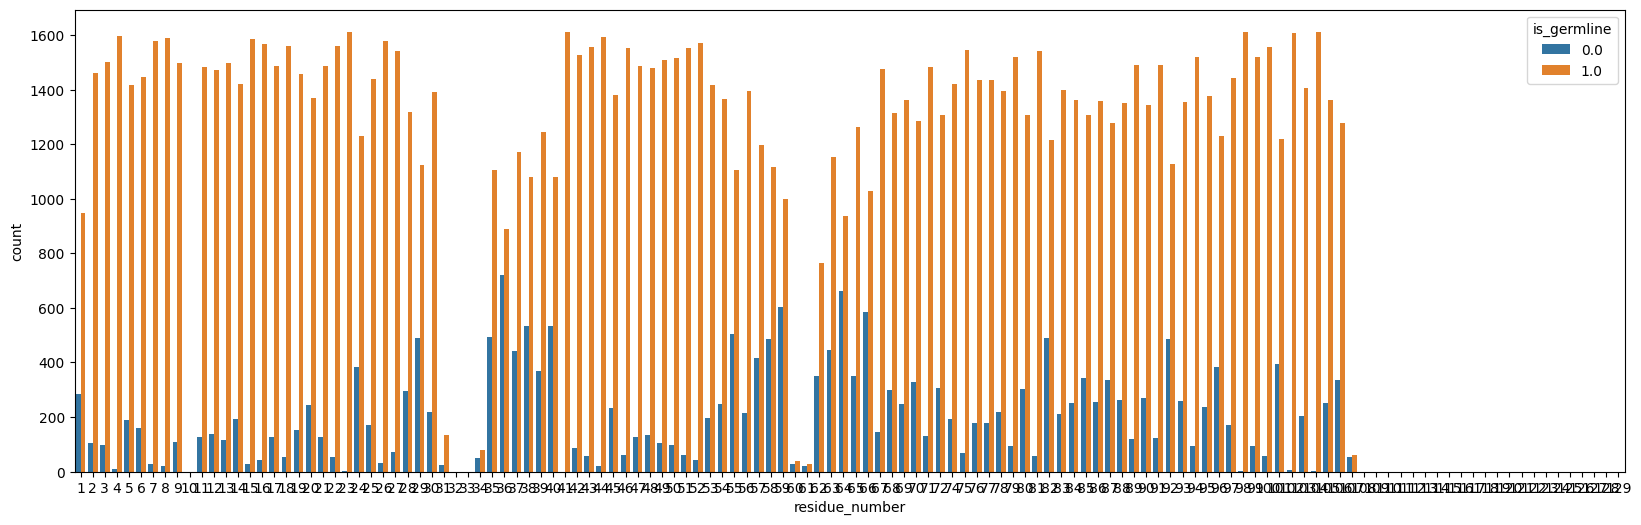

In [5]:
# sanity check for germline annotations, most sites should be is_germline == True
fig, ax = plt.subplots(figsize=(20, 6))
sns.countplot(df, x='residue_number', hue='is_germline', ax=ax)

In [6]:
CDRS = list(range(27,39)) + list(range(56,66)) + list(range(105,117))

df['is_cdr'] = df.residue_number.isin(CDRS)

## Some general structural analysis

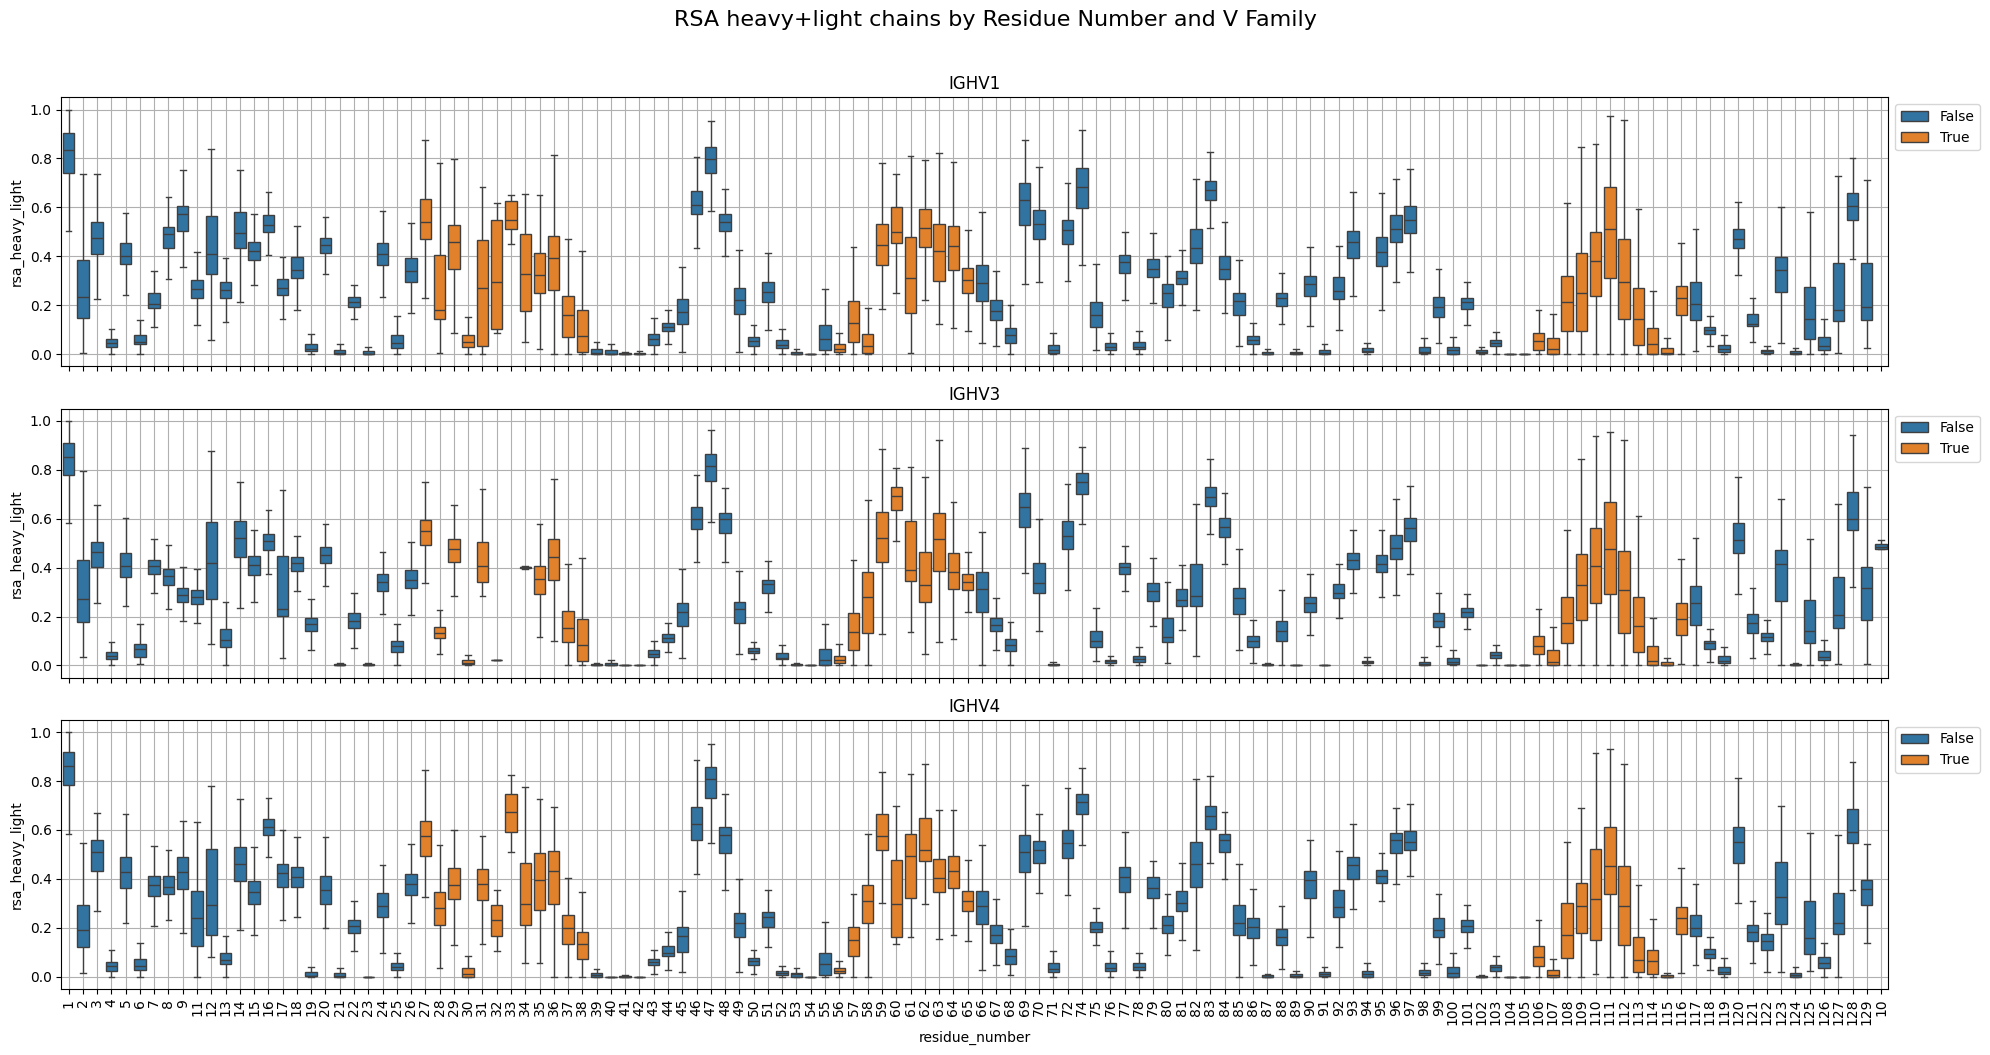

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(20, 10), sharex=True)

# Define the gene types you want to plot
v_families = ['IGHV1', 'IGHV3', 'IGHV4']

for i, gene_type in enumerate(v_families):
    # Filter data for each gene type
    filtered_data = df[(df.v_family_heavy == gene_type)]
    
    # Create countplot for each subplot
    sns.boxplot(data=filtered_data, x='residue_number', y='rsa_heavy_light', showfliers=False, ax=axes[i], hue='is_cdr')

    # Set title for each subplot
    axes[i].set_title(f'{gene_type}')
    
    # Rotate x labels for better readability
    axes[i].tick_params(axis='x', rotation=90)

    axes[i].grid()

    axes[i].legend(loc='upper left', bbox_to_anchor=(1, 1))

# Adjust layout to prevent overlap
plt.tight_layout()
# set title for whole plot
plt.suptitle('RSA heavy+light chains by Residue Number and V Family', fontsize=16, y=1.05)
plt.show()

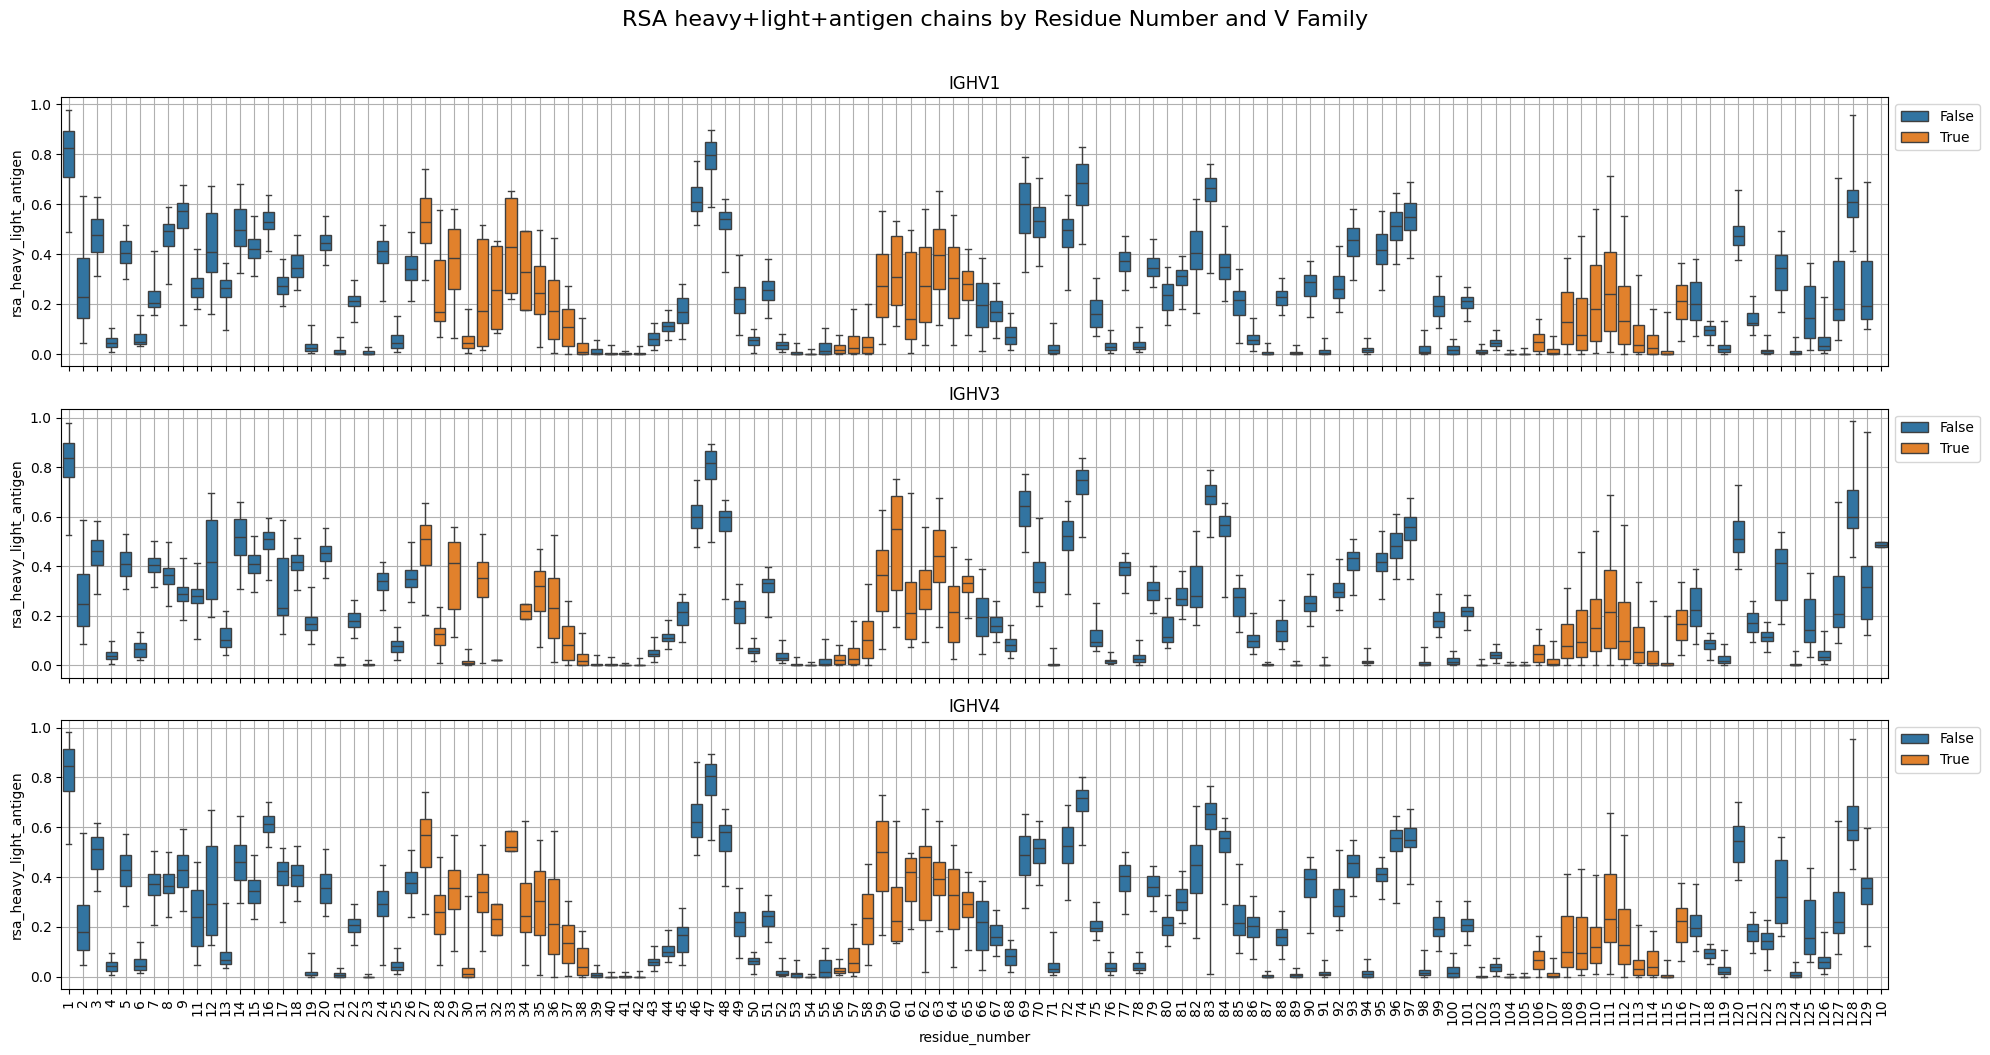

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(20, 10), sharex=True)

# Define the gene types you want to plot
v_families = ['IGHV1', 'IGHV3', 'IGHV4']

for i, gene_type in enumerate(v_families):
    # Filter data for each gene type
    filtered_data = df[(df.v_family_heavy == gene_type)]
    
    # Create countplot for each subplot
    sns.boxplot(data=filtered_data, x='residue_number', y='rsa_heavy_light_antigen', showfliers=False, ax=axes[i], hue='is_cdr', whis=[5,95])

    # Set title for each subplot
    axes[i].set_title(f'{gene_type}')
    
    # Rotate x labels for better readability
    axes[i].tick_params(axis='x', rotation=90)

    axes[i].grid()

    axes[i].legend(loc='upper left', bbox_to_anchor=(1, 1))


# Adjust layout to prevent overlap
plt.tight_layout()
# set title for whole plot
plt.suptitle('RSA heavy+light+antigen chains by Residue Number and V Family', fontsize=16, y=1.05)
plt.show()

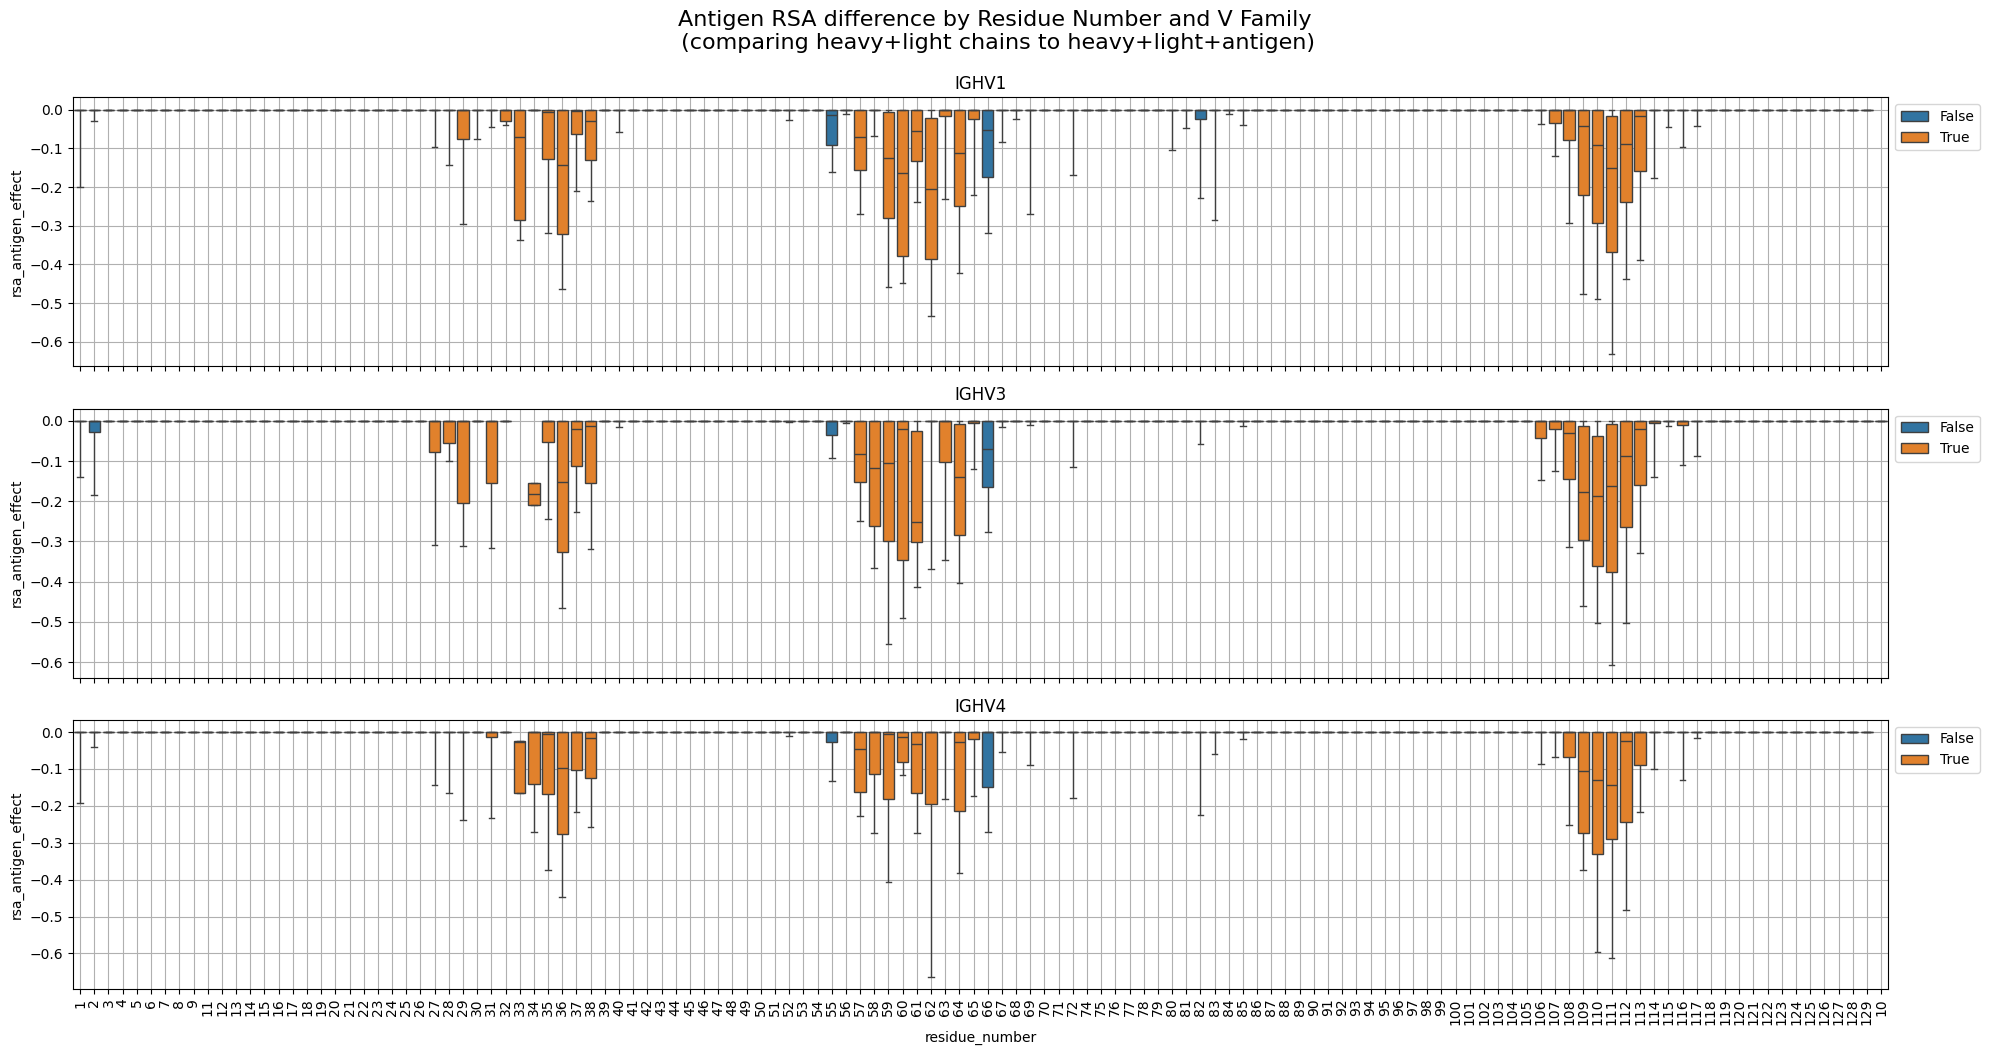

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(20, 10), sharex=True)

# Define the gene types you want to plot
v_families = ['IGHV1', 'IGHV3', 'IGHV4']

for i, gene_type in enumerate(v_families):
    # Filter data for each gene type
    filtered_data = df[(df.v_family_heavy == gene_type)]
    
    # Create countplot for each subplot
    sns.boxplot(data=filtered_data, x='residue_number', y='rsa_antigen_effect', showfliers=False, ax=axes[i], hue='is_cdr', whis=[5,95])

    # Set title for each subplot
    axes[i].set_title(f'{gene_type}')
    
    # Rotate x labels for better readability
    axes[i].tick_params(axis='x', rotation=90)

    axes[i].grid()

    axes[i].legend(loc='upper left', bbox_to_anchor=(1, 1))


# Adjust layout to prevent overlap
plt.tight_layout()
# set title for whole plot
plt.suptitle('Antigen RSA difference by Residue Number and V Family\n (comparing heavy+light chains to heavy+light+antigen)', fontsize=16, y=1.05)
plt.show()

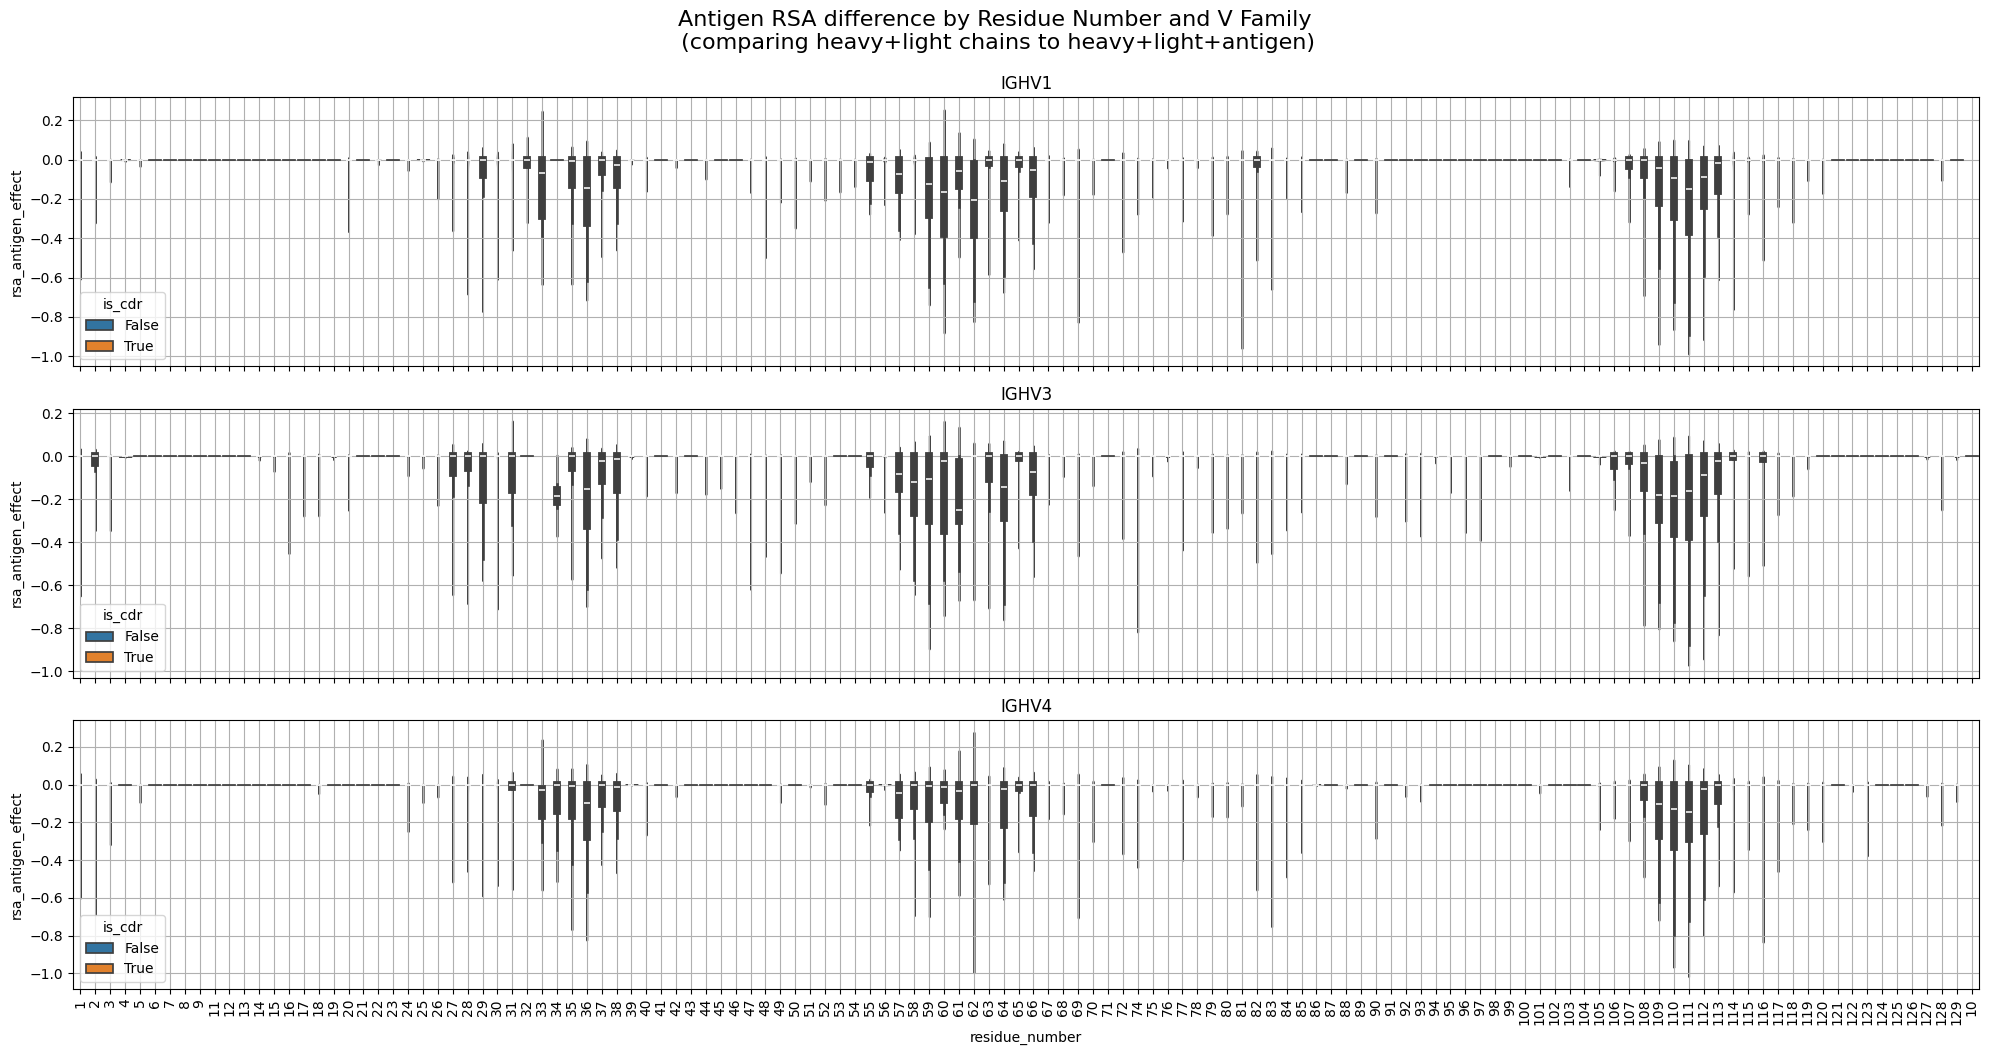

In [10]:
## What about CDR4? there's talk of another area that binds the antigen between CDR2 and CDR3 https://pmc.ncbi.nlm.nih.gov/articles/PMC7671036/
# examine with violinplot as well

fig, axes = plt.subplots(3, 1, figsize=(20, 10), sharex=True)

# Define the gene types you want to plot
v_families = ['IGHV1', 'IGHV3', 'IGHV4']

for i, gene_type in enumerate(v_families):
    # Filter data for each gene type
    filtered_data = df[(df.v_family_heavy == gene_type)]
    
    # Create countplot for each subplot
    sns.violinplot(data=filtered_data, x='residue_number', y='rsa_antigen_effect', ax=axes[i], hue='is_cdr')

    # Set title for each subplot
    axes[i].set_title(f'{gene_type}')
    
    # Rotate x labels for better readability
    axes[i].tick_params(axis='x', rotation=90)

    axes[i].grid()

# Adjust layout to prevent overlap
plt.tight_layout()
# set title for whole plot
plt.suptitle('Antigen RSA difference by Residue Number and V Family\n (comparing heavy+light chains to heavy+light+antigen)', fontsize=16, y=1.05)
plt.show()


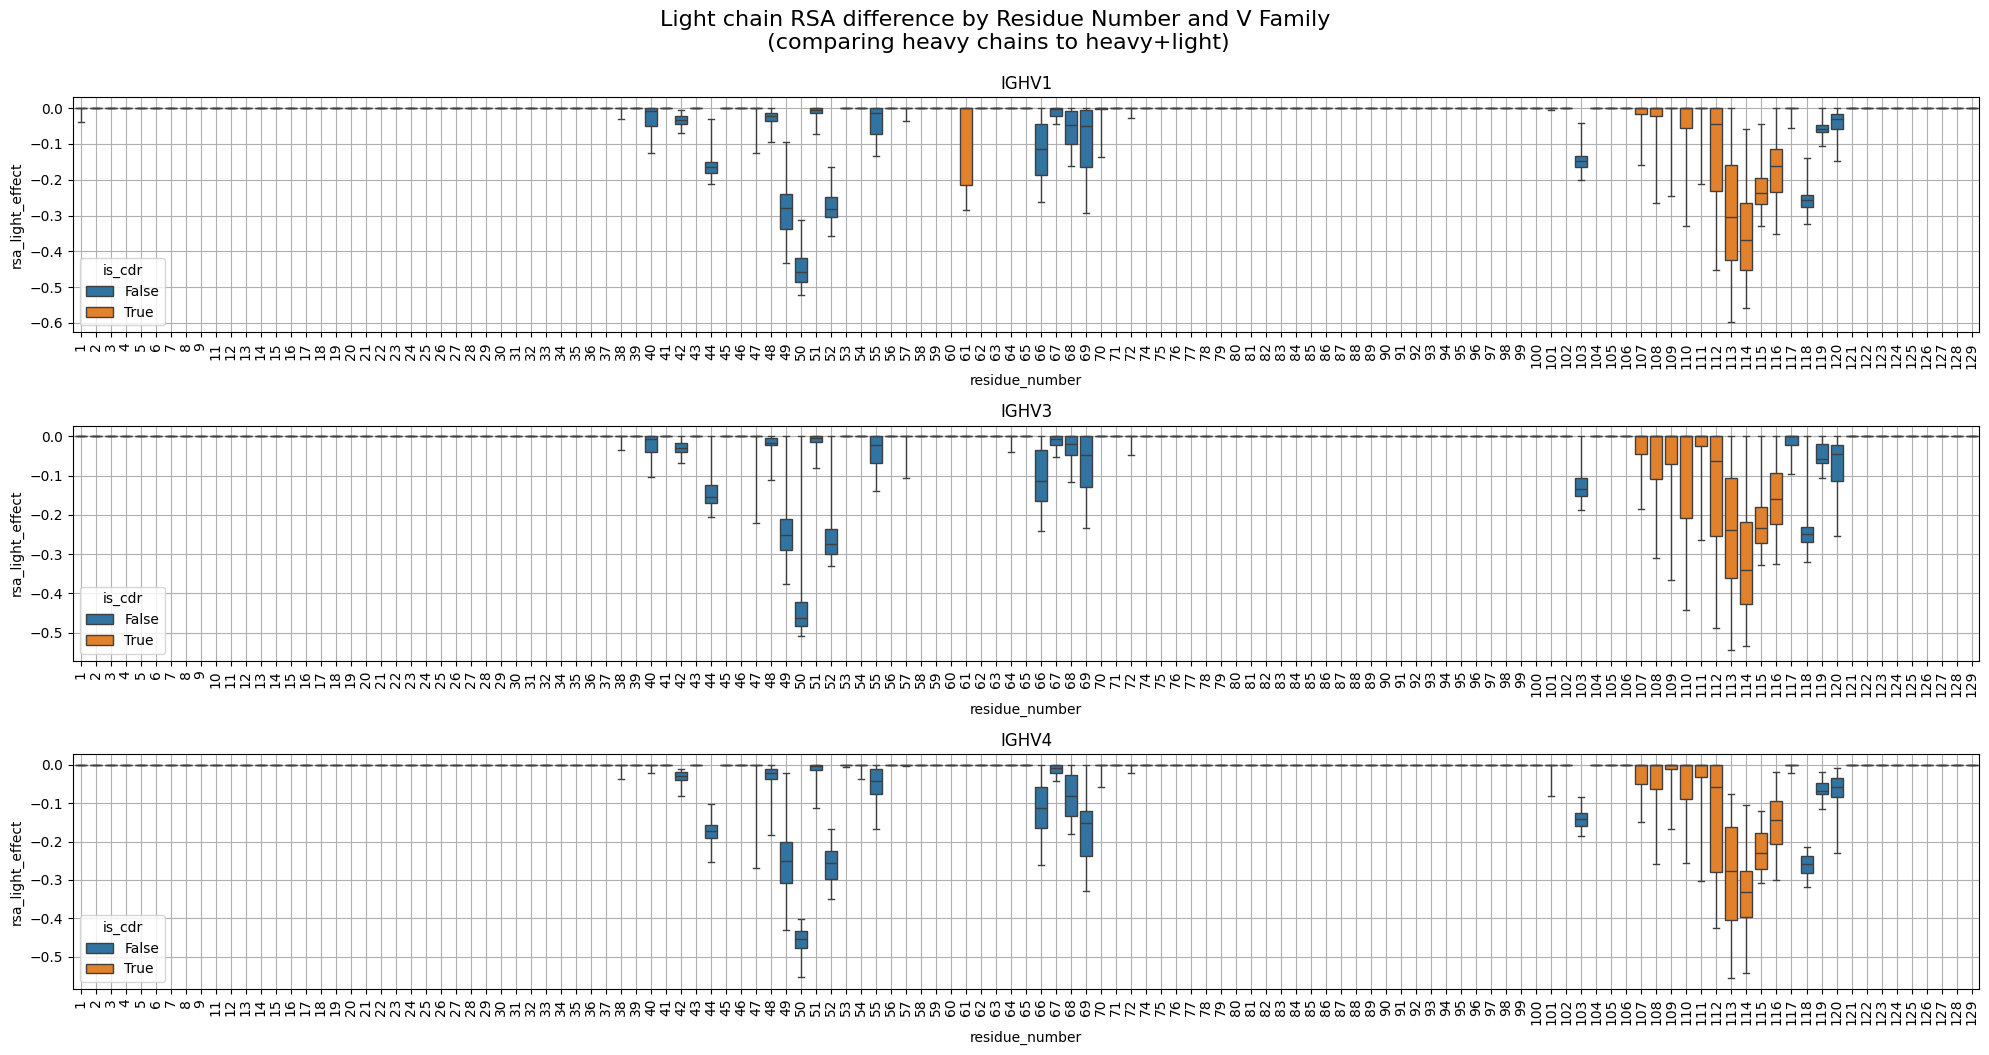

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(20, 10))

# Define the gene types you want to plot
v_families = ['IGHV1', 'IGHV3', 'IGHV4']

for i, gene_type in enumerate(v_families):
    # Filter data for each gene type
    filtered_data = df[(df.v_family_heavy == gene_type)]
    
    # Create countplot for each subplot
    sns.boxplot(data=filtered_data, x='residue_number', y='rsa_light_effect', showfliers=False, ax=axes[i], hue='is_cdr', whis=[5,95])

    # Set title for each subplot
    axes[i].set_title(f'{gene_type}')
    
    # Rotate x labels for better readability
    axes[i].tick_params(axis='x', rotation=90)

    axes[i].grid()

# Adjust layout to prevent overlap
plt.tight_layout()
plt.suptitle('Light chain RSA difference by Residue Number and V Family\n (comparing heavy chains to heavy+light)', fontsize=16, y=1.05)

plt.show()

## aggregate per v_family, site and germline amino acid for a better look

In [12]:
aggregated_rsa = df[df.is_germline == True].groupby(['v_family_heavy', 'residue_number', 'amino_acid']).agg({'is_germline':'count', 'rsa_heavy_only':'median', 'rsa_heavy_light':'median', 'rsa_heavy_light_antigen':'median', 'rsa_light_effect':'median', 'rsa_antigen_effect':'median'}).reset_index().rename(columns={'is_germline':'count'})  
aggregated_rsa

,v_family_heavy,residue_number,amino_acid,count,rsa_heavy_only,rsa_heavy_light,rsa_heavy_light_antigen,rsa_light_effect,rsa_antigen_effect
0,IGHV1,1,E,9,0.905830,0.881166,0.881166,0.000000,0.0
1,IGHV1,1,Q,258,0.815556,0.813333,0.804444,0.000000,0.0
2,IGHV1,2,M,23,0.375000,0.375000,0.375000,0.000000,0.0
3,IGHV1,2,V,398,0.218391,0.218391,0.206897,0.000000,0.0
4,IGHV1,3,Q,442,0.475556,0.475556,0.475556,0.000000,0.0
...,...,...,...,...,...,...,...,...,...
951,IGHV7,102,Y,20,0.000000,0.000000,0.000000,0.000000,0.0
952,IGHV7,103,Y,16,0.193916,0.038023,0.038023,-0.152091,0.0
953,IGHV7,104,C,21,0.000000,0.000000,0.000000,0.000000,0.0
954,IGHV7,105,A,15,0.000000,0.000000,0.000000,0.000000,0.0


<Axes: >

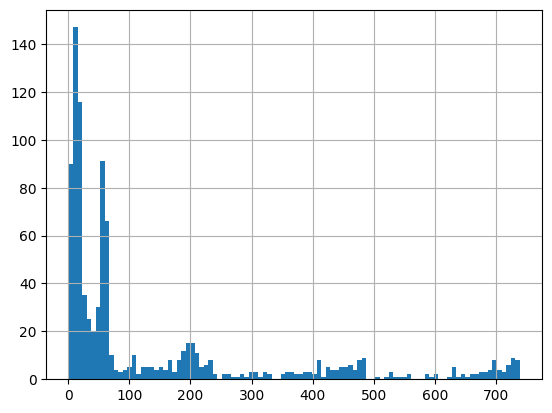

In [13]:
aggregated_rsa['count'].hist(bins=100)

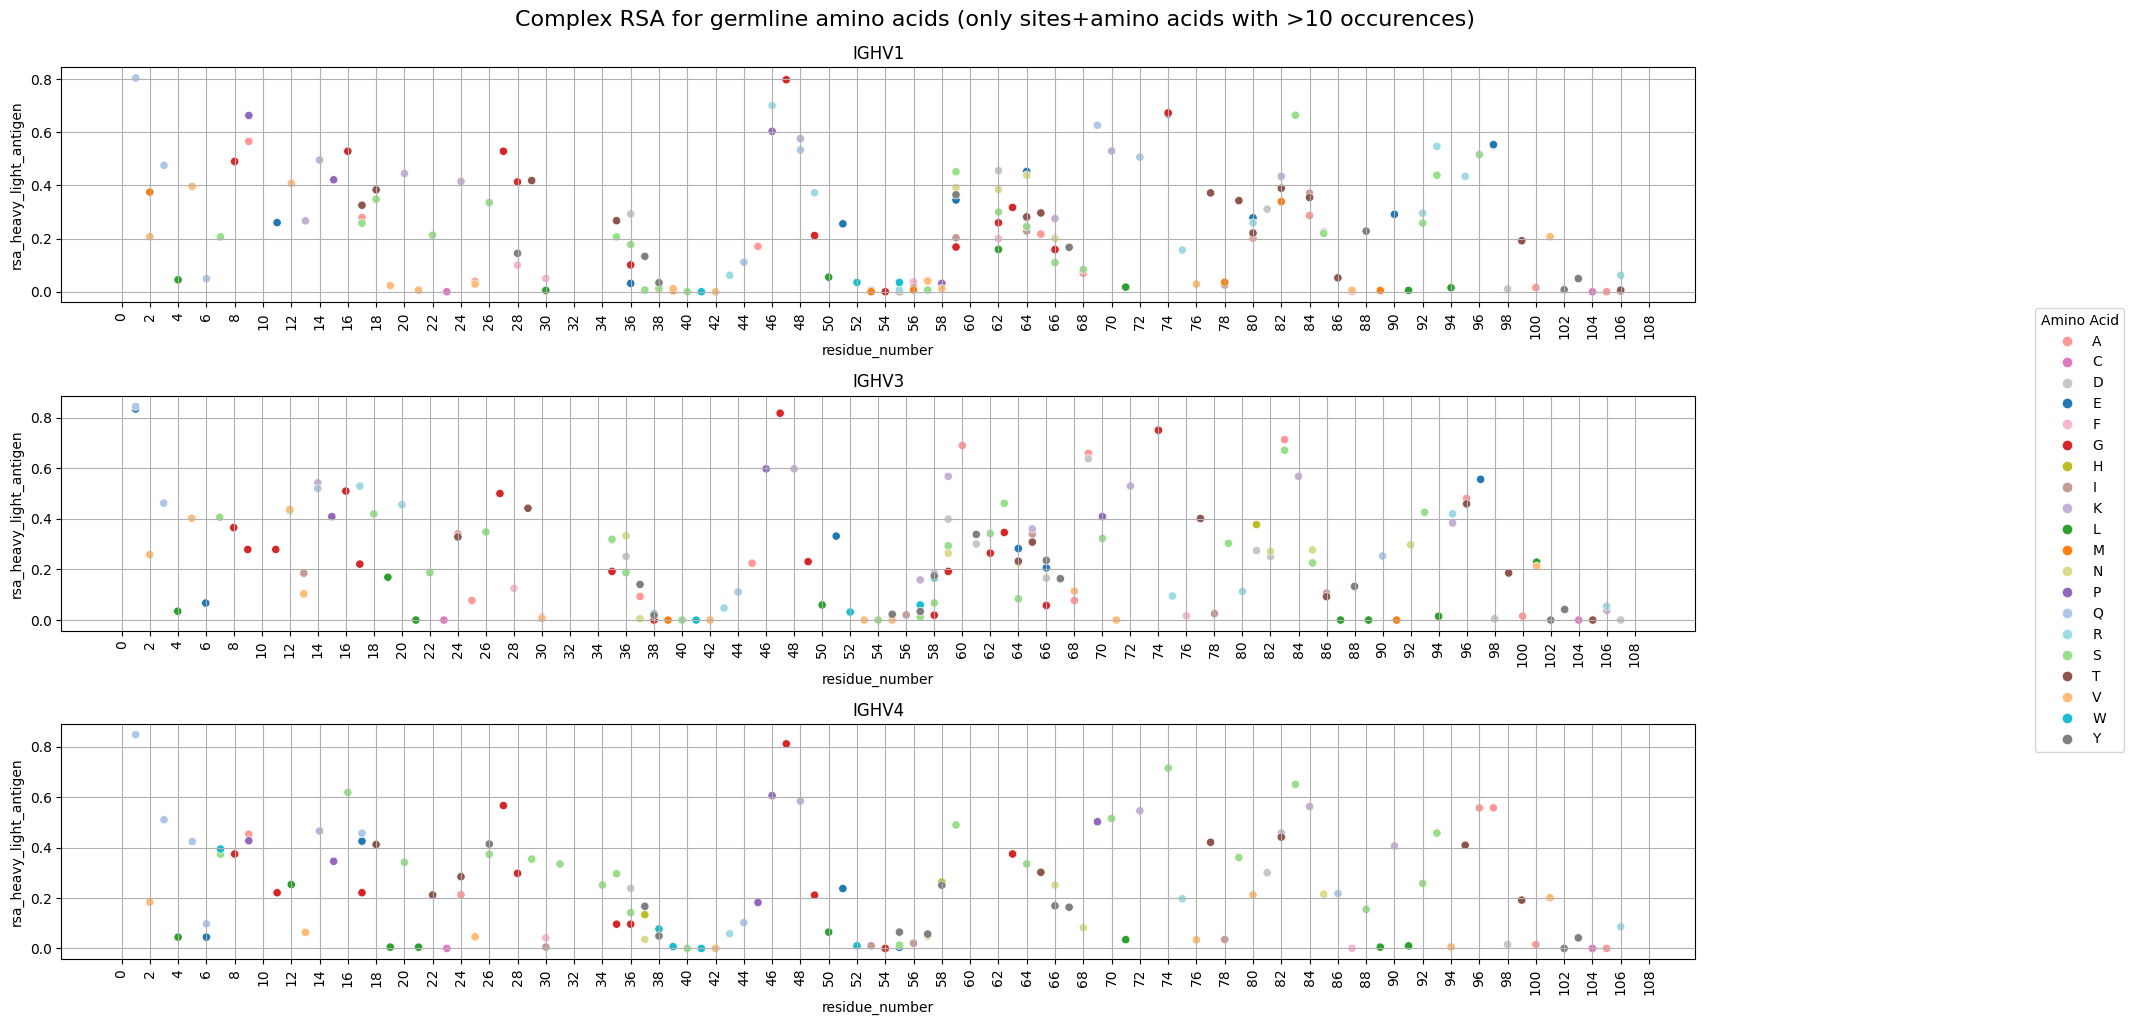

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(20, 10))

# Define the gene types you want to plot
v_families = ['IGHV1', 'IGHV3', 'IGHV4']

# Get all unique amino acids to create consistent color palette
all_amino_acids = aggregated_rsa['amino_acid'].unique()
palette = dict(zip(all_amino_acids, sns.color_palette('tab20', len(all_amino_acids))))

for i, gene_type in enumerate(v_families):
    # Filter data for each gene type
    filtered_data = aggregated_rsa[(aggregated_rsa.v_family_heavy == gene_type) & (aggregated_rsa['count'] > 10)]
    
    # Create scatterplot with consistent palette
    sns.scatterplot(
        data=filtered_data, 
        x='residue_number', 
        y='rsa_heavy_light_antigen', 
        hue='amino_acid', 
        ax=axes[i], 
        palette=palette,
        legend=False  # Turn off individual legends
    )
    
    axes[i].set_xticks(range(0, 110, 2))
    axes[i].tick_params(axis='x', rotation=90)
    axes[i].set_title(f'{gene_type}')
    axes[i].grid()

# Create shared legend
handles = []
labels = []
for aa in sorted(all_amino_acids):  # Sort for consistent order
    handles.append(plt.Line2D([0], [0], marker='o', color='w', 
                             markerfacecolor=palette[aa], markersize=8))
    labels.append(aa)

# Add legend to the figure
fig.legend(handles, labels, bbox_to_anchor=(1.02, 0.5), loc='center left', 
          borderaxespad=0., title='Amino Acid')

# Adjust layout to make room for legend
plt.tight_layout()
plt.subplots_adjust(right=0.85)  # Make space for legend
plt.suptitle('Complex RSA for germline amino acids (only sites+amino acids with >10 occurences)', fontsize=16, y=1.02)

plt.show()

Text(0.5, 1.0, 'delta-RSA (antigen effect) for germline amino acids\n (only sites+amino_acid with >10 occurrences)')

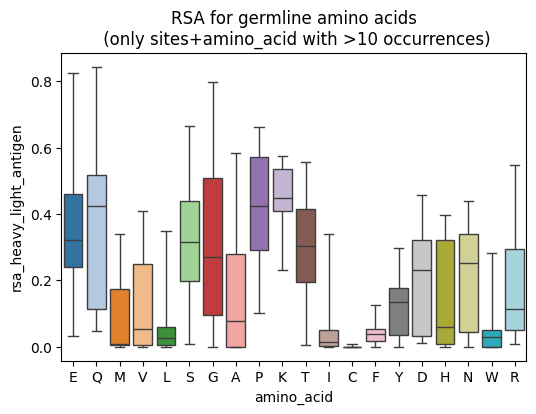

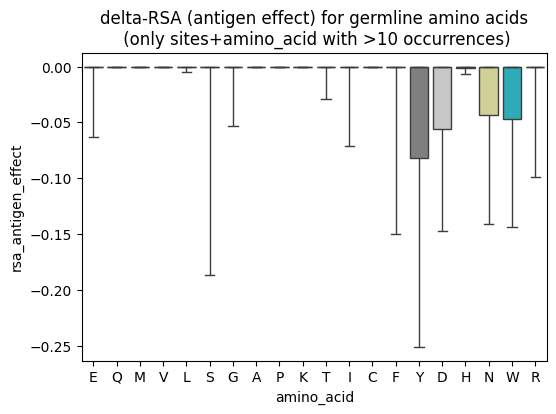

In [15]:
fig, ax  = plt.subplots(figsize=(6, 4))
sns.boxplot(aggregated_rsa, x='amino_acid', y='rsa_heavy_light_antigen', showfliers=False, whis=[5,95], hue='amino_acid', palette=palette)
ax.set_title('RSA for germline amino acids\n (only sites+amino_acid with >10 occurrences)')

fig, ax  = plt.subplots(figsize=(6, 4))
sns.boxplot(aggregated_rsa, x='amino_acid', y='rsa_antigen_effect', showfliers=False, whis=[5,95], hue='amino_acid', palette=palette)
ax.set_title('delta-RSA (antigen effect) for germline amino acids\n (only sites+amino_acid with >10 occurrences)')

# compare to entrenched sites

In [16]:
# Load entrenchment data
entrenchment_directory = '_output/entrenchment_analysis/'

# Load "within" files and "vs" files separately
within_dfs = []
vs_dfs = []

for f in os.listdir(entrenchment_directory):
    file_path = os.path.join(entrenchment_directory, f)
    
    if 'within' in f:
        temp_df = pd.read_csv(file_path)
        within_dfs.append(temp_df)
    elif 'vs' in f:
        temp_df = pd.read_csv(file_path)
        vs_dfs.append(temp_df)

# Combine dataframes
within_combined = pd.concat(within_dfs, axis=0) if within_dfs else pd.DataFrame()
vs_combined = pd.concat(vs_dfs, axis=0) if vs_dfs else pd.DataFrame()

# rename for solvent accessibiltity df compatibility
within_combined_renamed = within_combined.rename(columns={'site':'residue_number', 'v_family':'v_family_heavy'})
vs_combined_renamed = vs_combined.rename(columns={'site':'residue_number', 'v_family':'v_family_heavy'})





In [17]:
# filter aggregated_rsa to only incldue sites + amino acids with >10 occurrences
aggregated_rsa = aggregated_rsa[aggregated_rsa['count'] > 10]

### Show between v family entrenched sites


In [18]:
aggregated_rsa_entrenched = aggregated_rsa.copy()


# Create highlight indicator
highlight_set = set(
    zip(vs_combined_renamed['residue_number'], 
        vs_combined_renamed['amino_acid'], 
        vs_combined_renamed['v_family_heavy'])
)

# Add highlight column
aggregated_rsa_entrenched['is_highlighted'] = aggregated_rsa_entrenched.apply(
    lambda row: (row['residue_number'], row['amino_acid'], row['v_family_heavy']) in highlight_set,
    axis=1
)

# Create color mapping
aggregated_rsa_entrenched['color_by'] = aggregated_rsa_entrenched.apply(
    lambda row: row['amino_acid'] if row['is_highlighted'] else 'background',
    axis=1
)

# Create custom palette
unique_amino_acids = aggregated_rsa_entrenched[aggregated_rsa_entrenched['is_highlighted']]['amino_acid'].unique()
colors = sns.color_palette('tab20', len(unique_amino_acids))
palette_dict = dict(zip(unique_amino_acids, colors))
palette_dict['background'] = 'black'

# Split data into highlighted and background
highlighted_data = aggregated_rsa_entrenched[aggregated_rsa_entrenched['is_highlighted']]
background_data = aggregated_rsa_entrenched[~aggregated_rsa_entrenched['is_highlighted']]


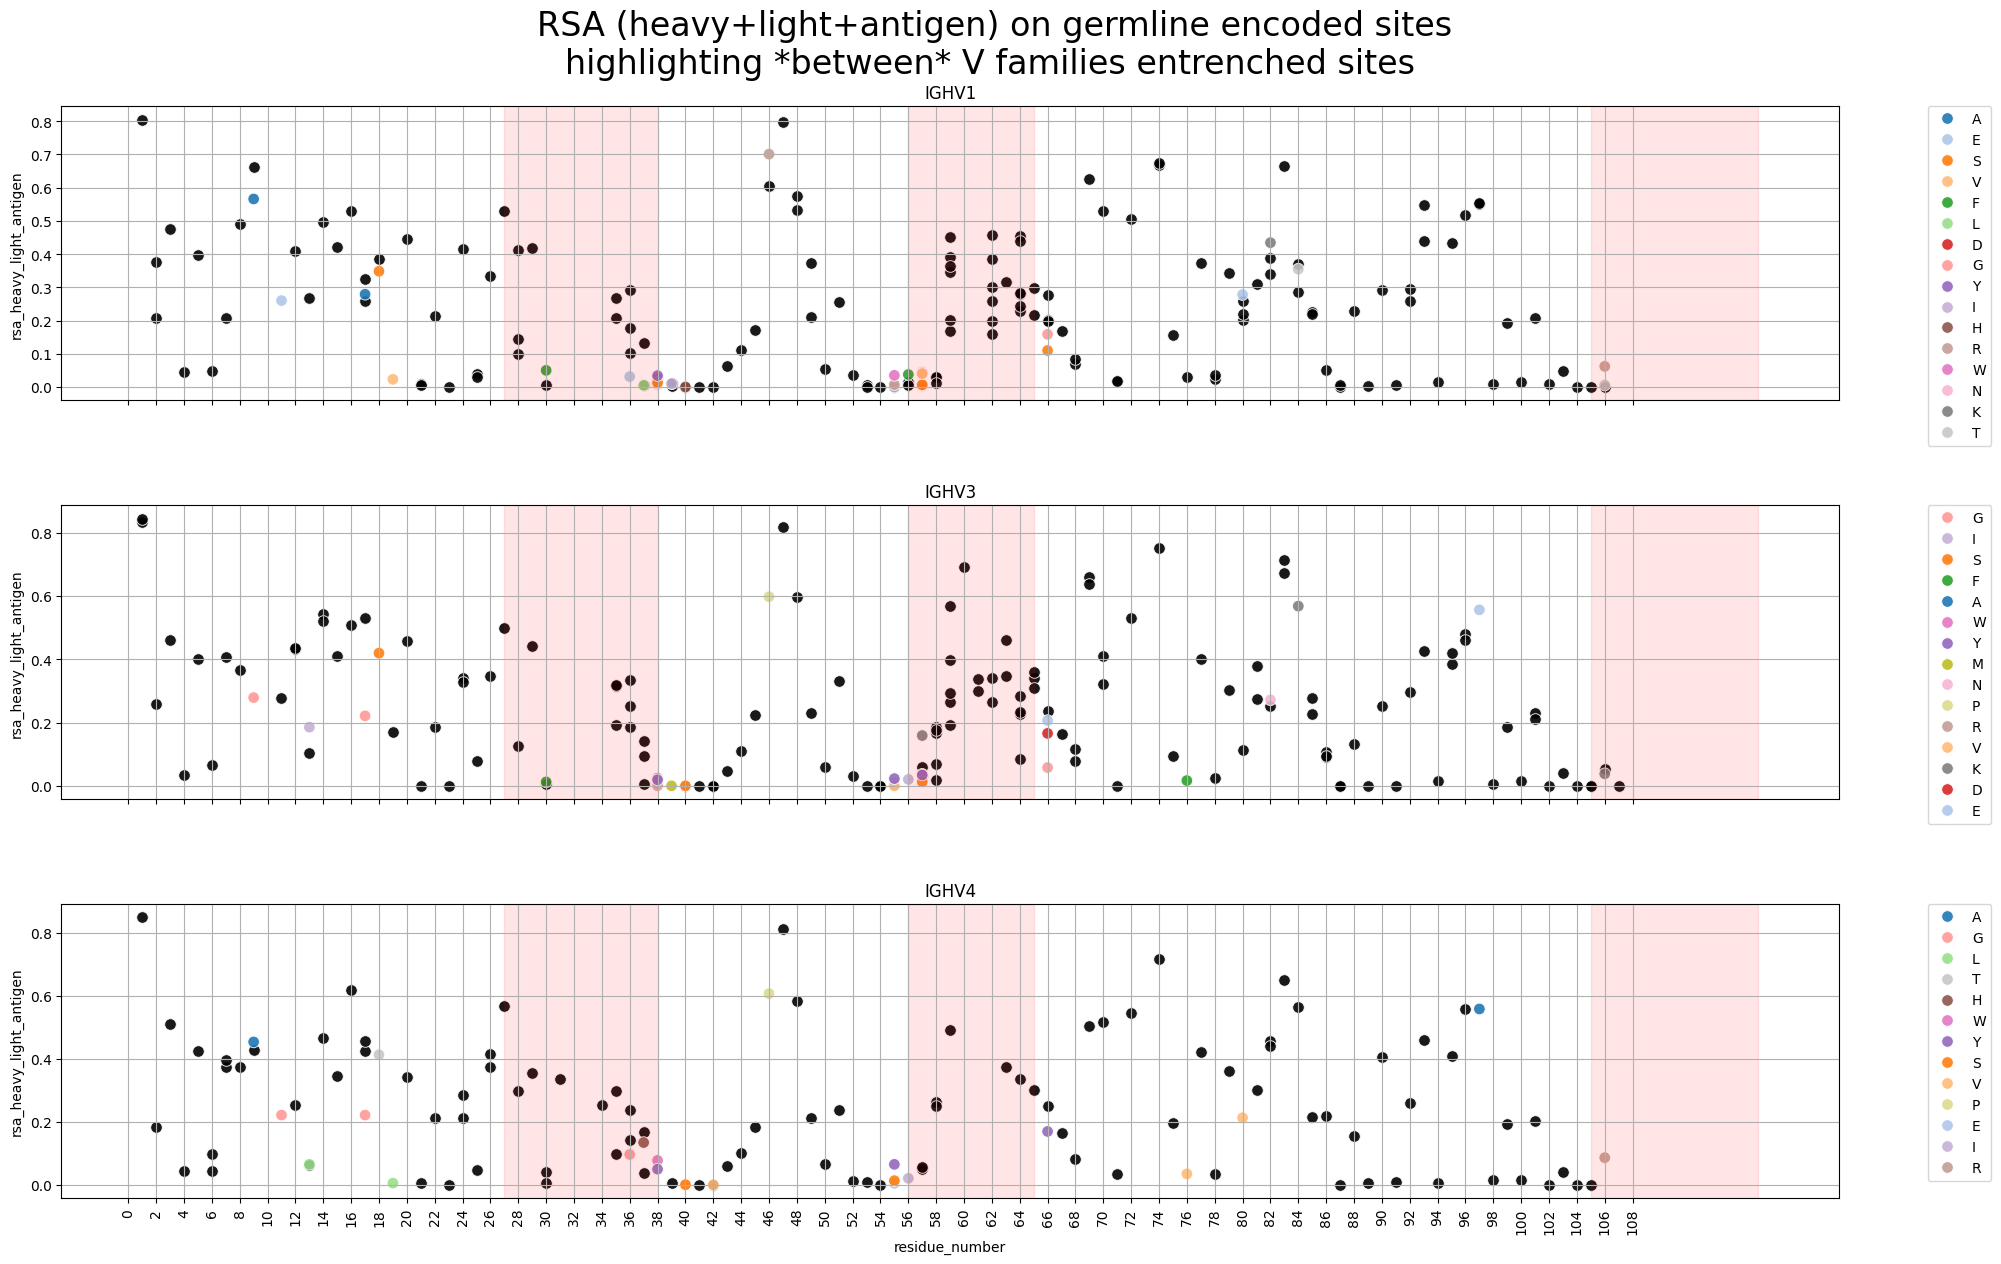

In [19]:
fig, axes = plt.subplots(3, 1, figsize=(20, 12), sharex=True)

# Define the gene types you want to plot
v_families = ['IGHV1', 'IGHV3', 'IGHV4']

for i, gene_type in enumerate(v_families):
    # Filter data for each gene type
    filtered_background_data = background_data[(background_data.v_family_heavy == gene_type)]
    filtered_highlighted_data = highlighted_data[(highlighted_data.v_family_heavy == gene_type)]

    
    sns.scatterplot(
        data=filtered_background_data, 
        x='residue_number', 
        y='rsa_heavy_light_antigen', 
        #style='v_family_heavy', 
        color='black',
        s=70,
        alpha=0.9,
        ax=axes[i]
    )

# Plot highlighted points on top
    sns.scatterplot(
        data=filtered_highlighted_data, 
        x='residue_number', 
        y='rsa_heavy_light_antigen', 
        #style='v_family_heavy', 
        hue='color_by', 
        s=70,
        alpha=0.9,
        ax=axes[i], 
        palette=palette_dict
    )
    # Set title for each subplot
    axes[i].set_title(f'{gene_type}')
    
    # Rotate x labels for better readability
    axes[i].tick_params(axis='x', rotation=90)
    axes[i].set_xticks(range(0, 110, 2))
    axes[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

    axes[i].grid()
    # Define CDR regions (1-based site numbering)
    cdr_regions = [(27, 38), (56, 65), (105, 117)]  # Example CDR1, CDR2, CDR3 regions
    # Add CDR background regions
    for cdr_start, cdr_end in cdr_regions:
        axes[i].axvspan(cdr_start, cdr_end, alpha=0.1, color='red', 
                label='CDR' if cdr_start == cdr_regions[0][0] else "")


# Adjust layout to prevent overlap
plt.tight_layout()
# set title for whole plot
plt.suptitle('RSA (heavy+light+antigen) on germline encoded sites\nhighlighting *between* V families entrenched sites ', fontsize=24, y=1.05)
plt.show()

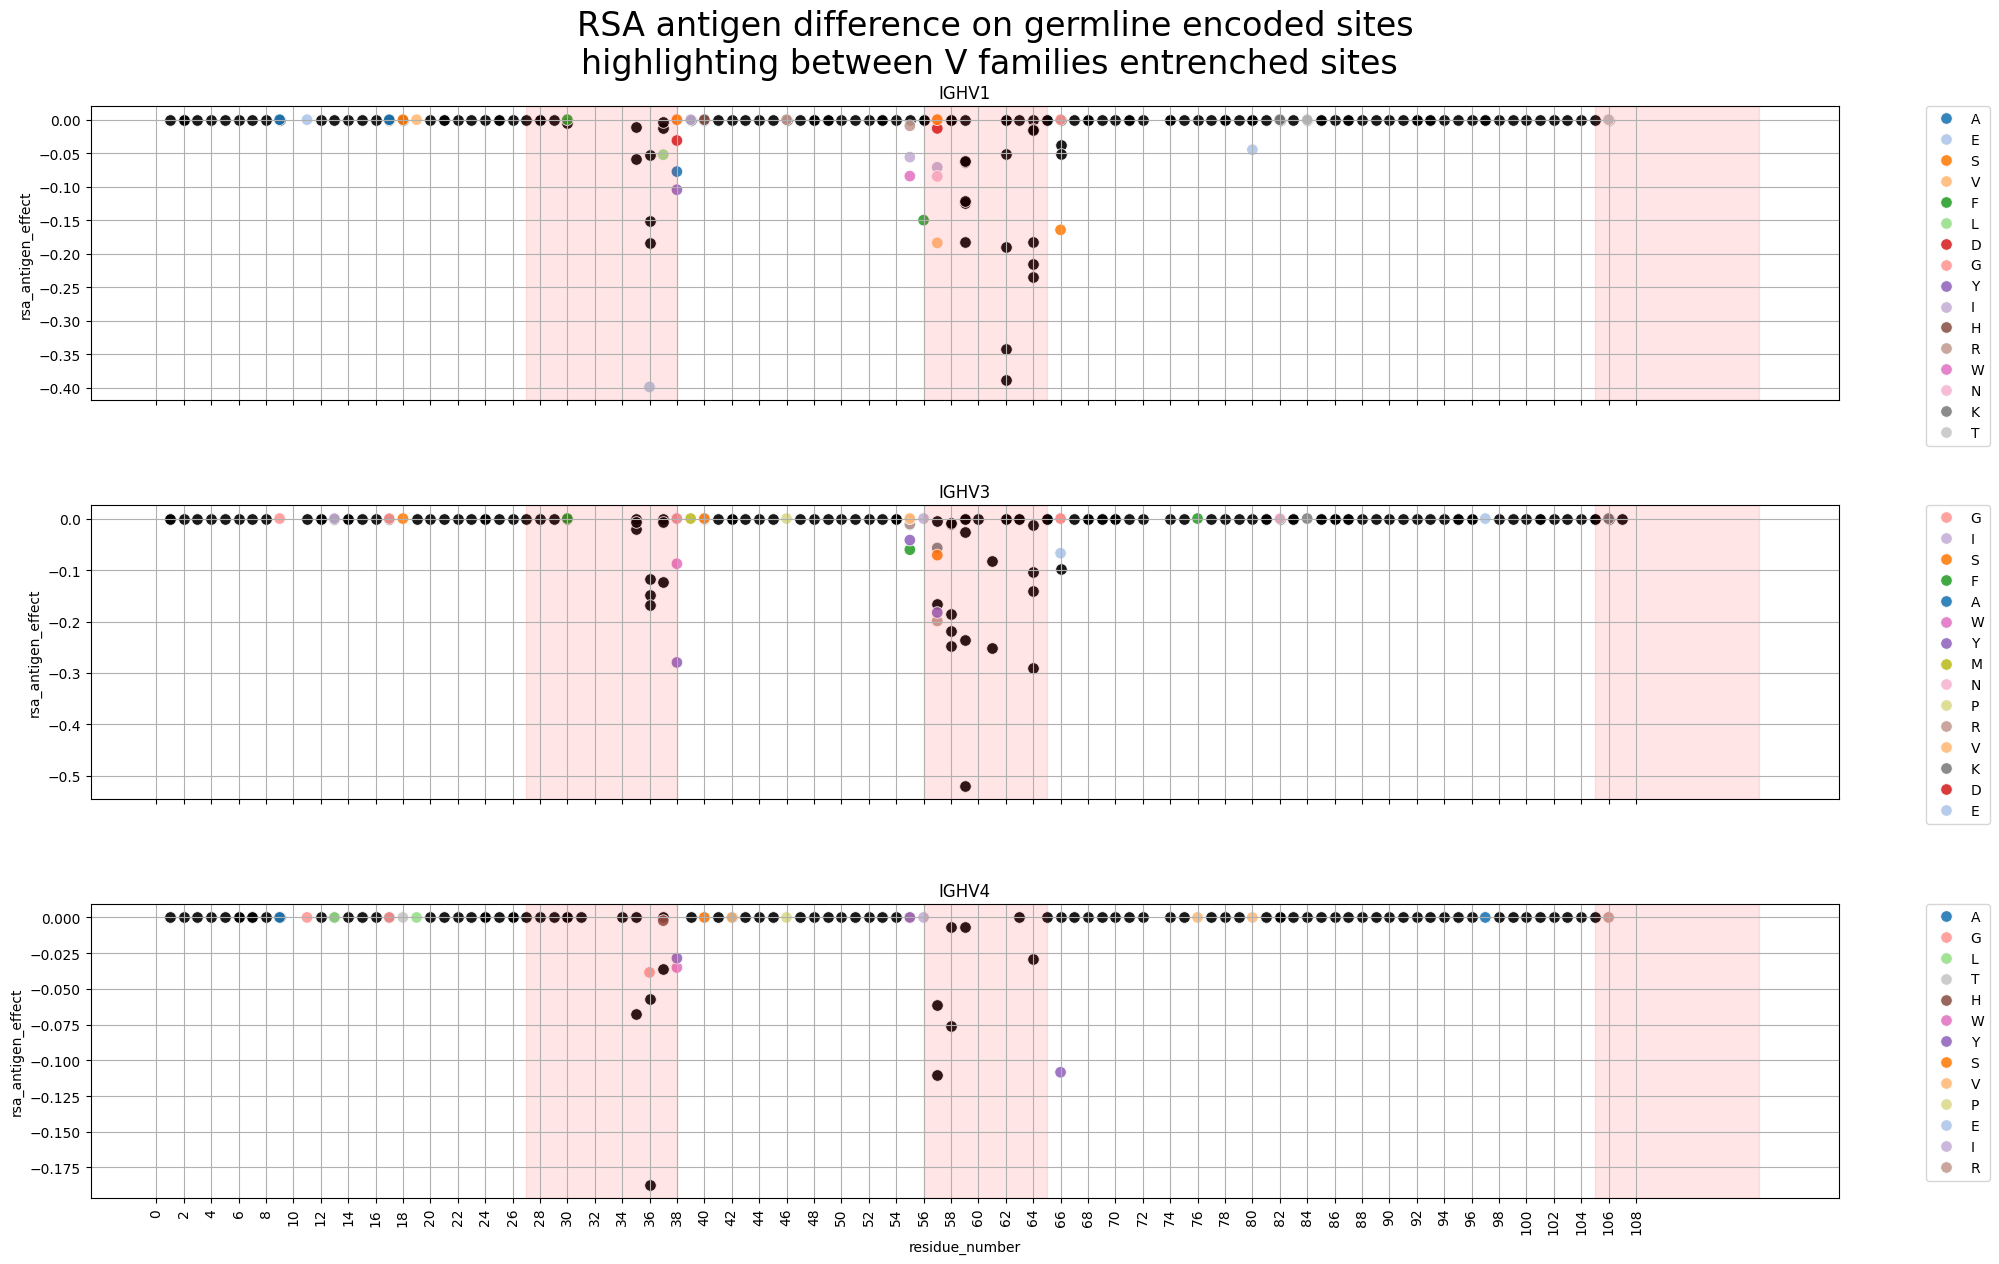

In [20]:
fig, axes = plt.subplots(3, 1, figsize=(20, 12), sharex=True)

# Define the gene types you want to plot
v_families = ['IGHV1', 'IGHV3', 'IGHV4']

for i, gene_type in enumerate(v_families):
    # Filter data for each gene type
    filtered_background_data = background_data[(background_data.v_family_heavy == gene_type)]
    filtered_highlighted_data = highlighted_data[(highlighted_data.v_family_heavy == gene_type)]

    
    sns.scatterplot(
        data=filtered_background_data, 
        x='residue_number', 
        y='rsa_antigen_effect', 
        #style='v_family_heavy', 
        color='black',
        s=70,
        alpha=0.9,
        ax=axes[i]
    )

# Plot highlighted points on top
    sns.scatterplot(
        data=filtered_highlighted_data, 
        x='residue_number', 
        y='rsa_antigen_effect', 
        #style='v_family_heavy', 
        hue='color_by', 
        s=70,
        alpha=0.9,
        ax=axes[i], 
        palette=palette_dict
    )
    # Set title for each subplot
    axes[i].set_title(f'{gene_type}')
    
    # Rotate x labels for better readability
    axes[i].tick_params(axis='x', rotation=90)
    axes[i].set_xticks(range(0, 110, 2))
    axes[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

    axes[i].grid()

    # Define CDR regions (1-based site numbering)
    cdr_regions = [(27, 38), (56, 65), (105, 117)]  # Example CDR1, CDR2, CDR3 regions
    # Add CDR background regions
    for cdr_start, cdr_end in cdr_regions:
        axes[i].axvspan(cdr_start, cdr_end, alpha=0.1, color='red', 
                label='CDR' if cdr_start == cdr_regions[0][0] else "")


# Adjust layout to prevent overlap
plt.tight_layout()
# set title for whole plot
plt.suptitle('RSA antigen difference on germline encoded sites\nhighlighting between V families entrenched sites ', fontsize=24, y=1.05)
plt.show()

#### Show within v family entrenched sites


In [21]:
aggregated_rsa_entrenched = aggregated_rsa.copy()


# Create highlight indicator
highlight_set = set(
    zip(within_combined_renamed['residue_number'], 
        within_combined_renamed['amino_acid'], 
        within_combined_renamed['v_family_heavy'])
)

# Add highlight column
aggregated_rsa_entrenched['is_highlighted'] = aggregated_rsa_entrenched.apply(
    lambda row: (row['residue_number'], row['amino_acid'], row['v_family_heavy']) in highlight_set,
    axis=1
)

# Create color mapping
aggregated_rsa_entrenched['color_by'] = aggregated_rsa_entrenched.apply(
    lambda row: row['amino_acid'] if row['is_highlighted'] else 'background',
    axis=1
)

# Create custom palette
unique_amino_acids = aggregated_rsa_entrenched[aggregated_rsa_entrenched['is_highlighted']]['amino_acid'].unique()
colors = sns.color_palette('tab20', len(unique_amino_acids))
palette_dict = dict(zip(unique_amino_acids, colors))
palette_dict['background'] = 'black'

# Split data into highlighted and background
highlighted_data = aggregated_rsa_entrenched[aggregated_rsa_entrenched['is_highlighted']]
background_data = aggregated_rsa_entrenched[~aggregated_rsa_entrenched['is_highlighted']]



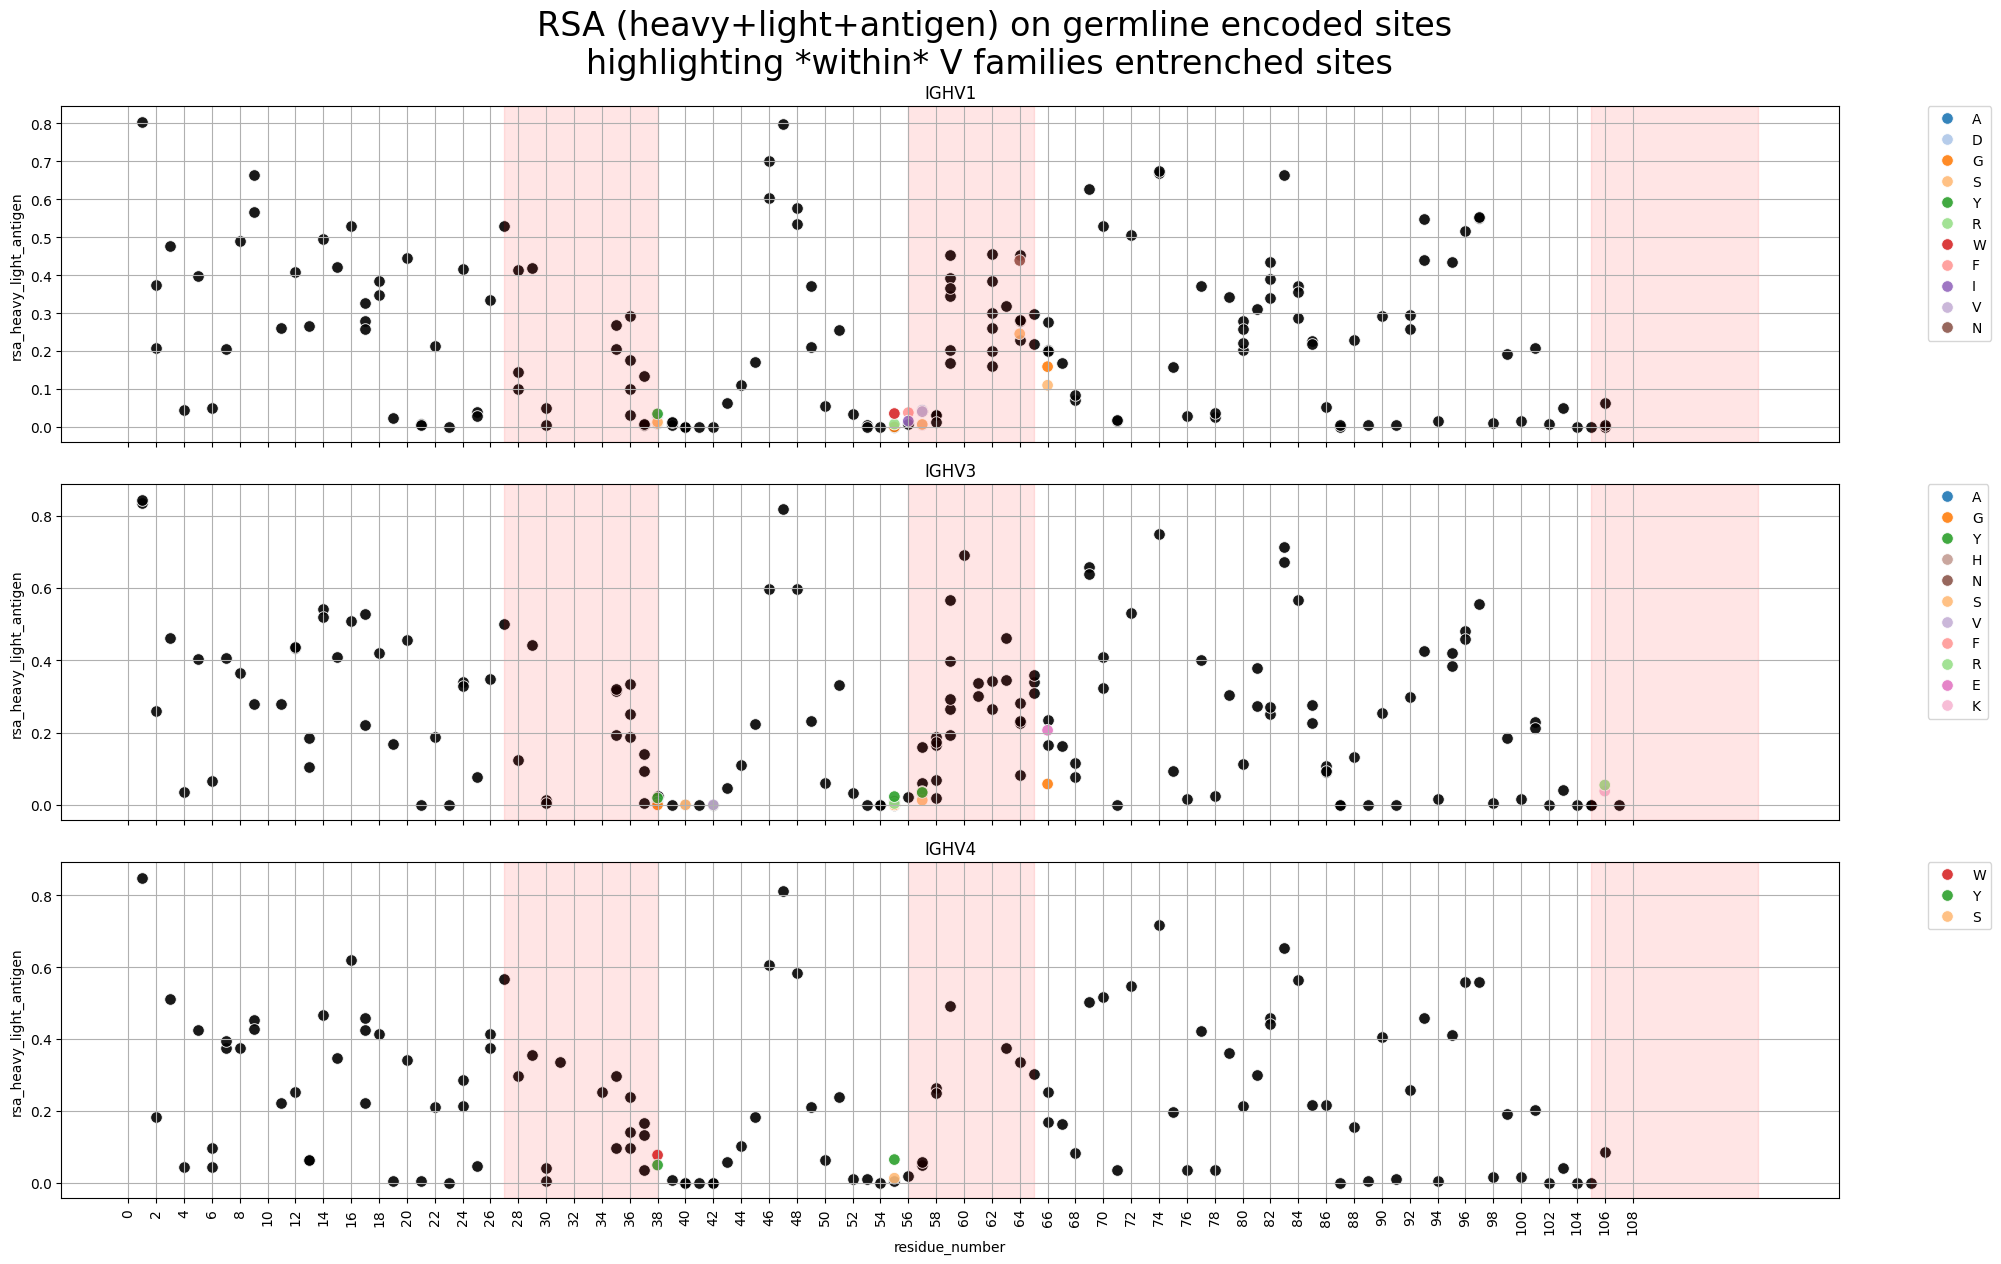

In [22]:
fig, axes = plt.subplots(3, 1, figsize=(20, 12), sharex=True)

# Define the gene types you want to plot
v_families = ['IGHV1', 'IGHV3', 'IGHV4']

for i, gene_type in enumerate(v_families):
    # Filter data for each gene type
    filtered_background_data = background_data[(background_data.v_family_heavy == gene_type)]
    filtered_highlighted_data = highlighted_data[(highlighted_data.v_family_heavy == gene_type)]

    
    sns.scatterplot(
        data=filtered_background_data, 
        x='residue_number', 
        y='rsa_heavy_light_antigen', 
        #style='v_family_heavy', 
        color='black',
        s=70,
        alpha=0.9,
        ax=axes[i]
    )

# Plot highlighted points on top
    sns.scatterplot(
        data=filtered_highlighted_data, 
        x='residue_number', 
        y='rsa_heavy_light_antigen', 
        #style='v_family_heavy', 
        hue='color_by', 
        s=70,
        alpha=0.9,
        ax=axes[i], 
        palette=palette_dict
    )
    # Set title for each subplot
    axes[i].set_title(f'{gene_type}')
    
    # Rotate x labels for better readability
    axes[i].tick_params(axis='x', rotation=90)
    axes[i].set_xticks(range(0, 110, 2))
    axes[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

    axes[i].grid()
    # Define CDR regions (1-based site numbering)
    cdr_regions = [(27, 38), (56, 65), (105, 117)]  # Example CDR1, CDR2, CDR3 regions
    # Add CDR background regions
    for cdr_start, cdr_end in cdr_regions:
        axes[i].axvspan(cdr_start, cdr_end, alpha=0.1, color='red', 
                label='CDR' if cdr_start == cdr_regions[0][0] else "")


# Adjust layout to prevent overlap
plt.tight_layout()
# set title for whole plot
plt.suptitle('RSA (heavy+light+antigen) on germline encoded sites\nhighlighting *within* V families entrenched sites ', fontsize=24, y=1.05)
plt.show()

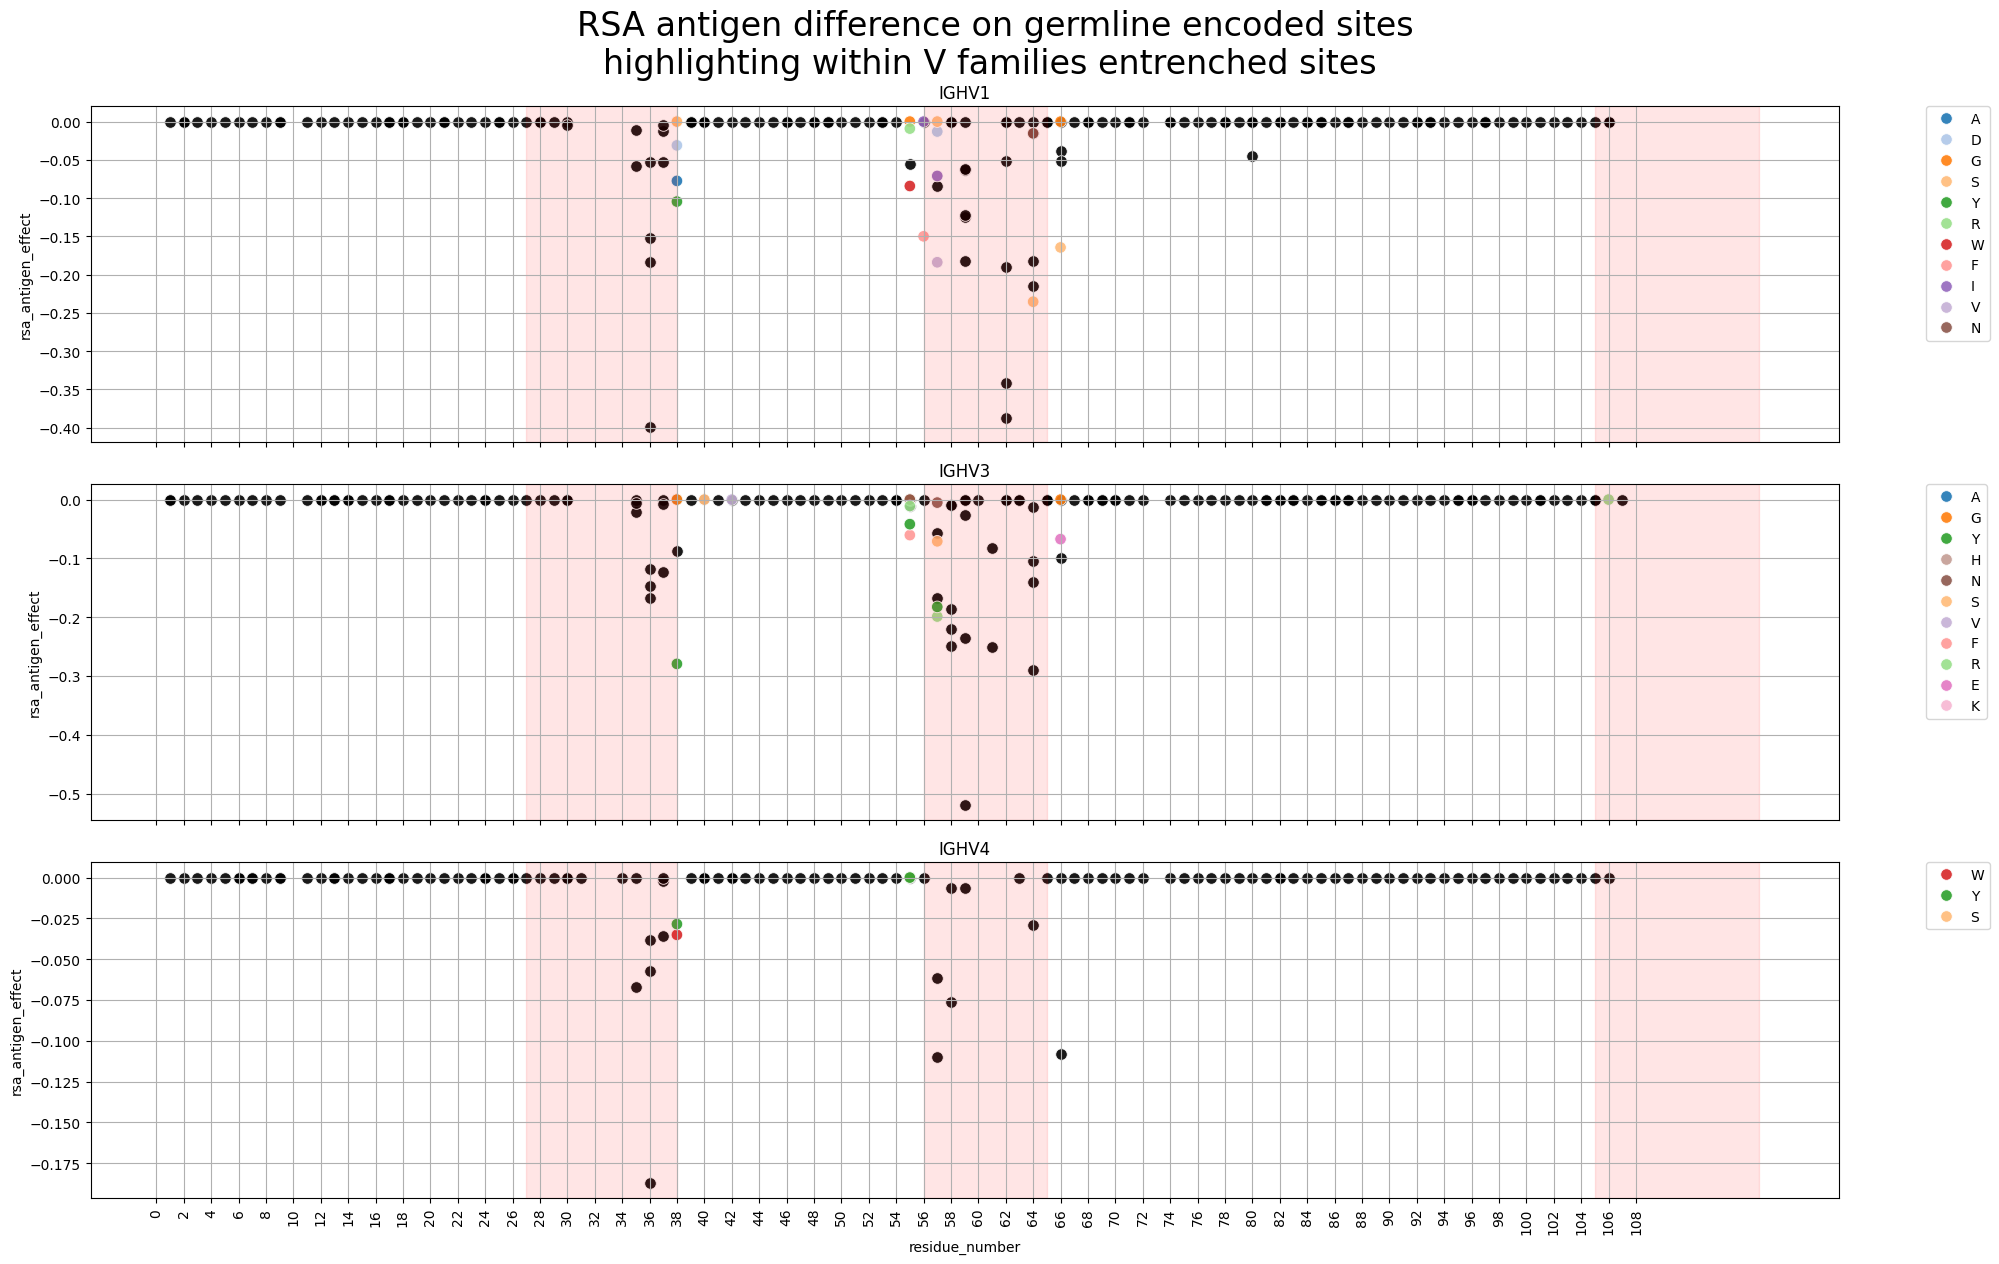

In [23]:
fig, axes = plt.subplots(3, 1, figsize=(20, 12), sharex=True)

# Define the gene types you want to plot
v_families = ['IGHV1', 'IGHV3', 'IGHV4']

for i, gene_type in enumerate(v_families):
    # Filter data for each gene type
    filtered_background_data = background_data[(background_data.v_family_heavy == gene_type)]
    filtered_highlighted_data = highlighted_data[(highlighted_data.v_family_heavy == gene_type)]

    
    sns.scatterplot(
        data=filtered_background_data, 
        x='residue_number', 
        y='rsa_antigen_effect', 
        #style='v_family_heavy', 
        color='black',
        s=70,
        alpha=0.9,
        ax=axes[i]
    )

# Plot highlighted points on top
    sns.scatterplot(
        data=filtered_highlighted_data, 
        x='residue_number', 
        y='rsa_antigen_effect', 
        #style='v_family_heavy', 
        hue='color_by', 
        s=70,
        alpha=0.9,
        ax=axes[i], 
        palette=palette_dict
    )
    # Set title for each subplot
    axes[i].set_title(f'{gene_type}')
    
    # Rotate x labels for better readability
    axes[i].tick_params(axis='x', rotation=90)
    axes[i].set_xticks(range(0, 110, 2))
    axes[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

    axes[i].grid()
        # Define CDR regions (1-based site numbering)
    cdr_regions = [(27, 38), (56, 65), (105, 117)]  # Example CDR1, CDR2, CDR3 regions
    # Add CDR background regions
    for cdr_start, cdr_end in cdr_regions:
        axes[i].axvspan(cdr_start, cdr_end, alpha=0.1, color='red', 
                label='CDR' if cdr_start == cdr_regions[0][0] else "")


# Adjust layout to prevent overlap
plt.tight_layout()
# set title for whole plot
plt.suptitle('RSA antigen difference on germline encoded sites\nhighlighting within V families entrenched sites ', fontsize=24, y=1.05)
plt.show()

## Examine specific sites


In [24]:
def examine_site(df_vfamily, site, suptitle):
    fig, ax = plt.subplots(2, 3, figsize=(20,12))
    ax = ax.flatten()
    fig.subplots_adjust(wspace=0.4, hspace=0.3)
    sns.countplot(df_vfamily[df_vfamily.residue_number == site], x='amino_acid', hue='is_germline', ax=ax[0])
    ax[0].set_title(f'Amino acid identities and is_germline')
    
    # only look at amino acids that are the gemrline sometimes
    germline_aas = df_vfamily[(df_vfamily.residue_number == site) & (df_vfamily.is_germline == True)].amino_acid.drop_duplicates().tolist()

    sns.boxplot(df_vfamily[(df_vfamily.residue_number == site) & (df_vfamily.amino_acid.isin(germline_aas))], x='amino_acid', y='rsa_antigen_effect', showfliers=False, hue='is_germline', ax=ax[1], whis=[5,95])
    #sns.violinplot(df_vfamily[(df_vfamily.residue_number == site) & (df_vfamily.amino_acid.isin(germline_aas))], x='amino_acid', y='rsa_antigen_effect', hue='is_germline', ax=ax[1])

    ax[1].set_title(f'RSA difference caused by antigen binding')

    sns.scatterplot(df_vfamily[(df_vfamily.residue_number == site) & (df_vfamily.is_germline == True)], x='rsa_heavy_light_antigen', y='rsa_heavy_light', hue='amino_acid', ax=ax[2])
    ax[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    ax[2].plot([0, 1], [0, 1], 'k--', alpha=0.7)
    ax[2].set_title(f'RSA difference caused by antigen binding (germline only)')

    sns.boxplot(df_vfamily[(df_vfamily.residue_number == site) & (df_vfamily.amino_acid.isin(germline_aas))], x='amino_acid', y='rsa_light_effect', showfliers=False, hue='is_germline', ax=ax[4], whis=[5,95])
    ax[4].set_title(f'RSA difference caused by light chain')

    
    sns.scatterplot(df_vfamily[(df_vfamily.residue_number == site) & (df_vfamily.is_germline == True)], x='rsa_heavy_light', y='rsa_heavy_only', hue='amino_acid', ax=ax[5])
    ax[5].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    ax[5].plot([0, 1], [0, 1], 'k--', alpha=0.7)
    ax[5].set_title(f'RSA difference caused by light chain (germline only)')

    fig.suptitle(suptitle)


df_v3 = df[df.v_family_heavy == 'IGHV3']
df_v1 = df[df.v_family_heavy == 'IGHV1']
df_v4 = df[df.v_family_heavy == 'IGHV4']


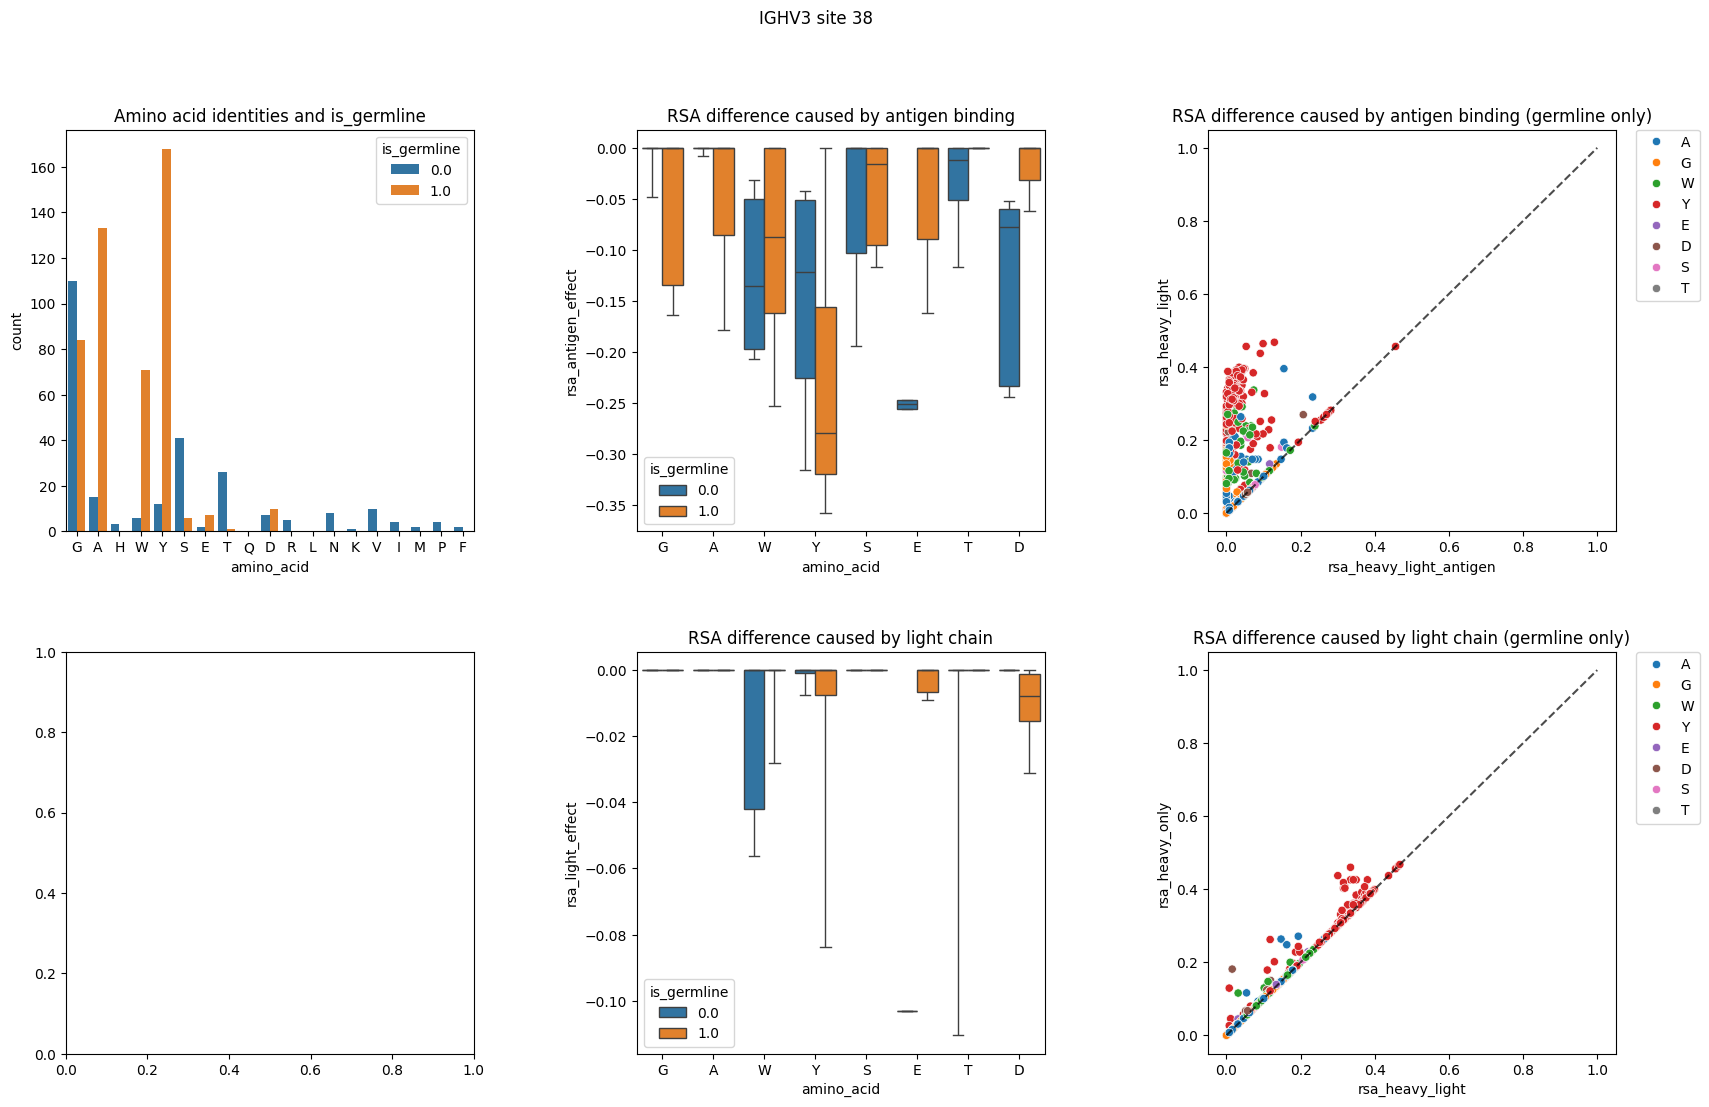

In [25]:
examine_site(df_v3, 38, 'IGHV3 site 38')


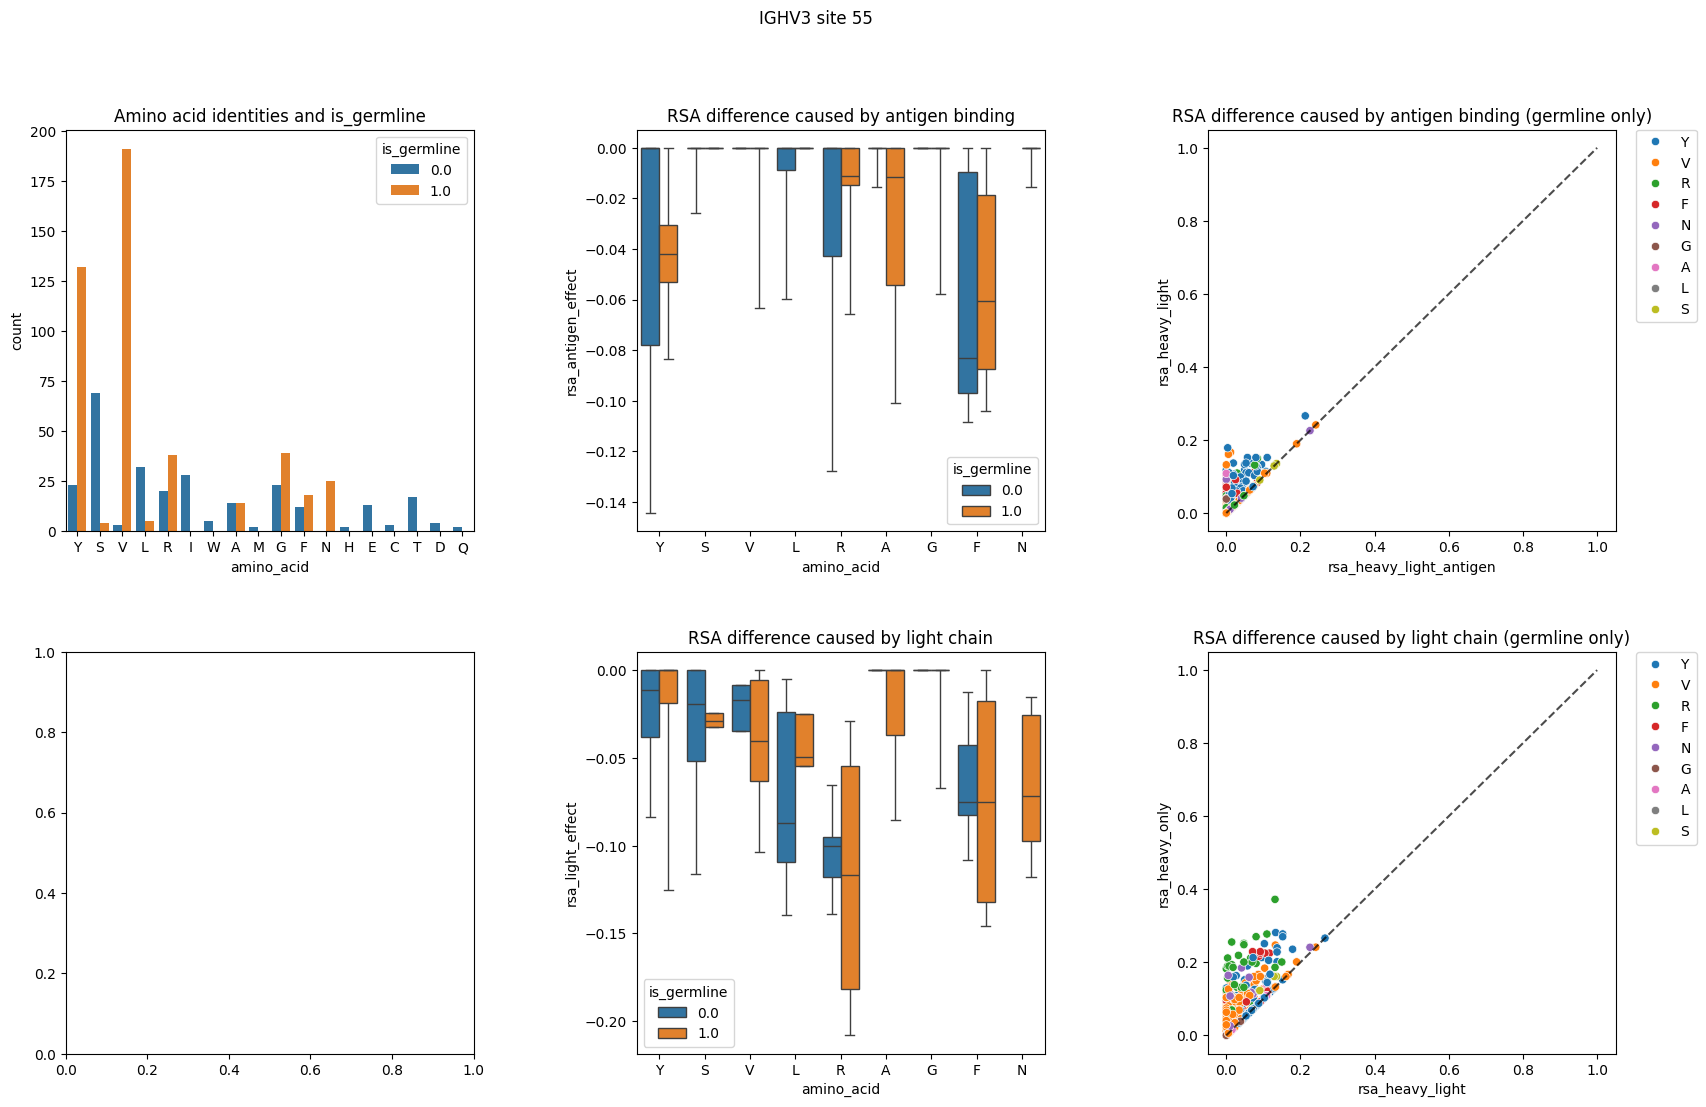

In [26]:
examine_site(df_v3, 55, 'IGHV3 site 55')


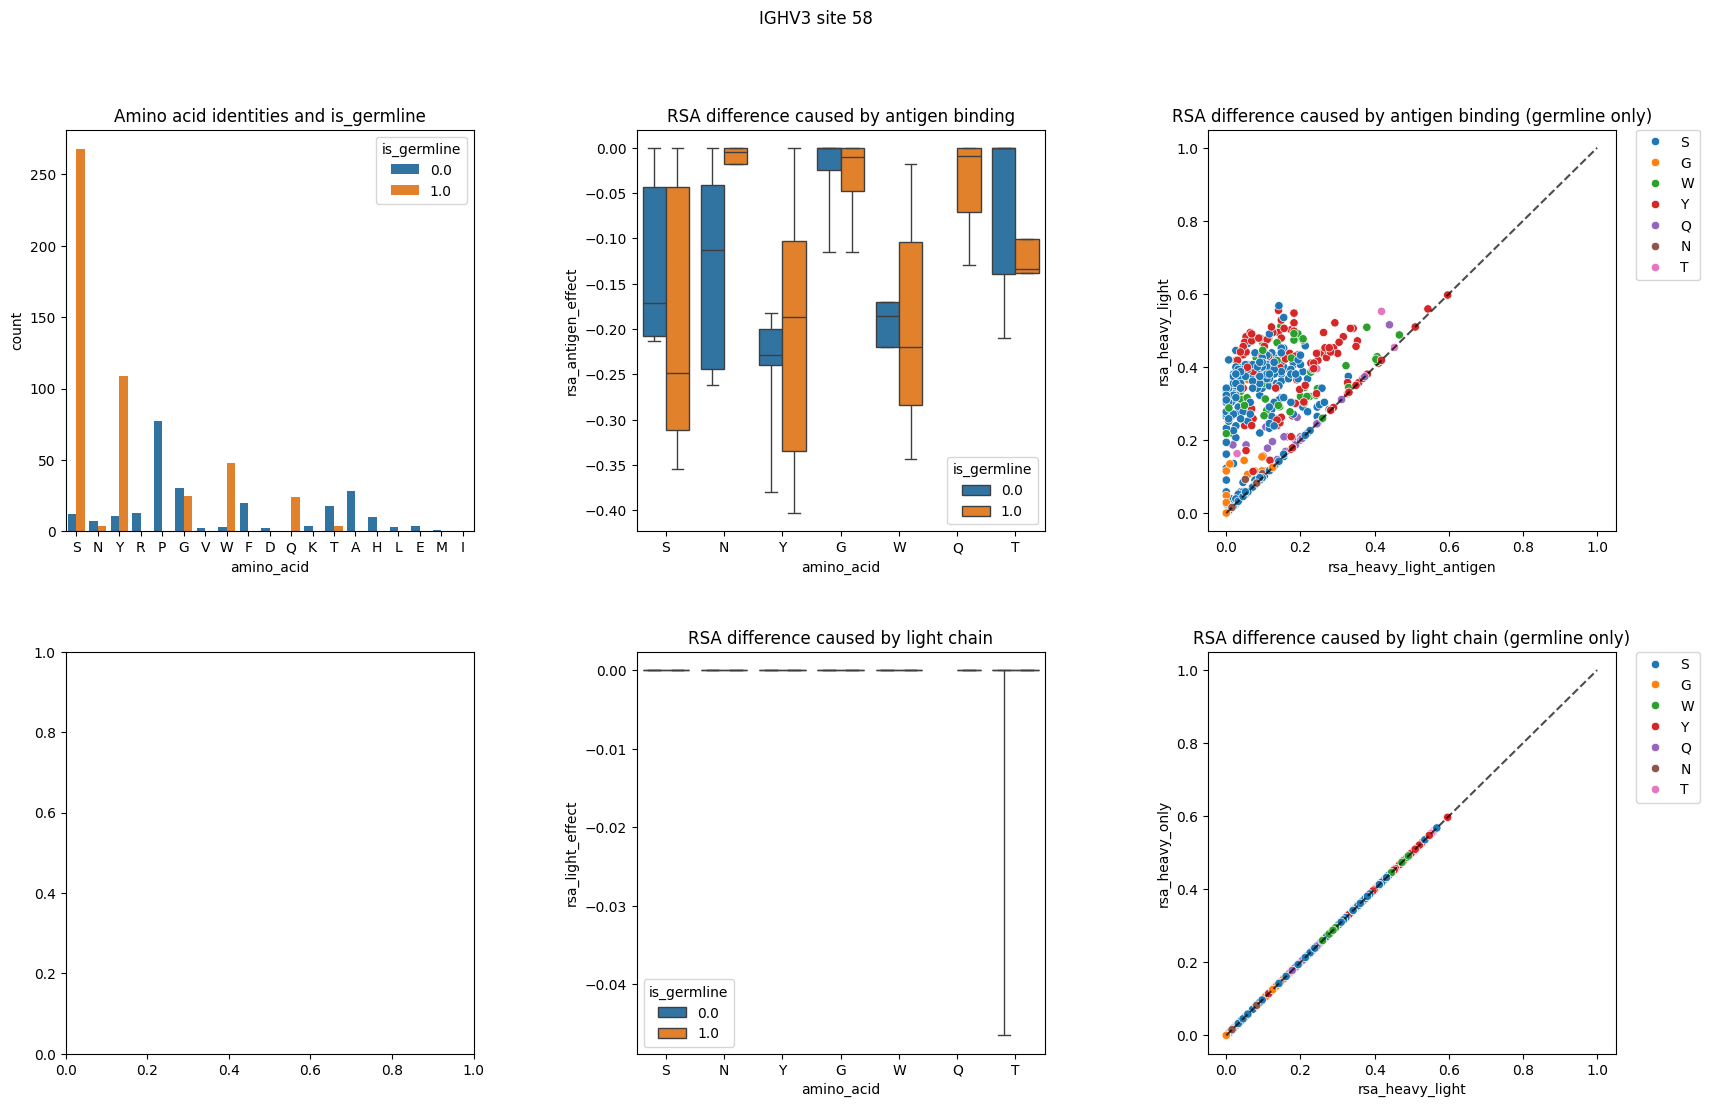

In [27]:
examine_site(df_v3, 58, 'IGHV3 site 58')


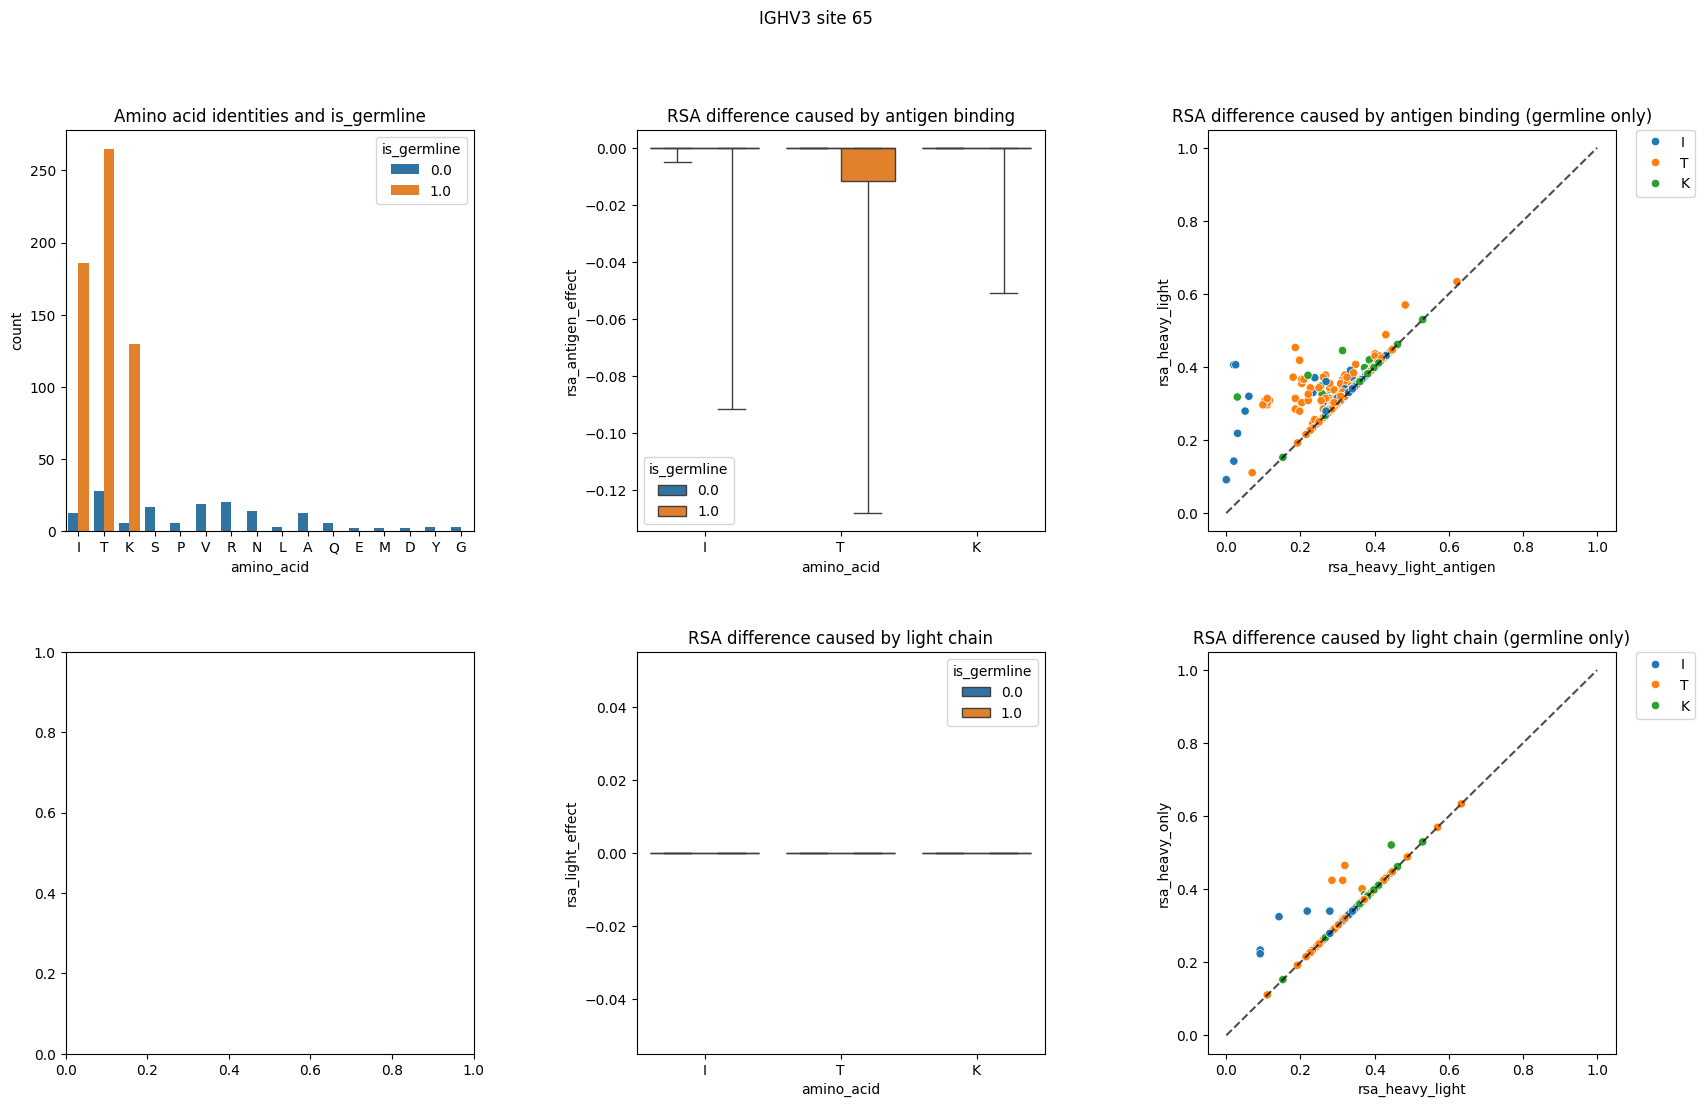

In [28]:
examine_site(df_v3, 65, 'IGHV3 site 65')


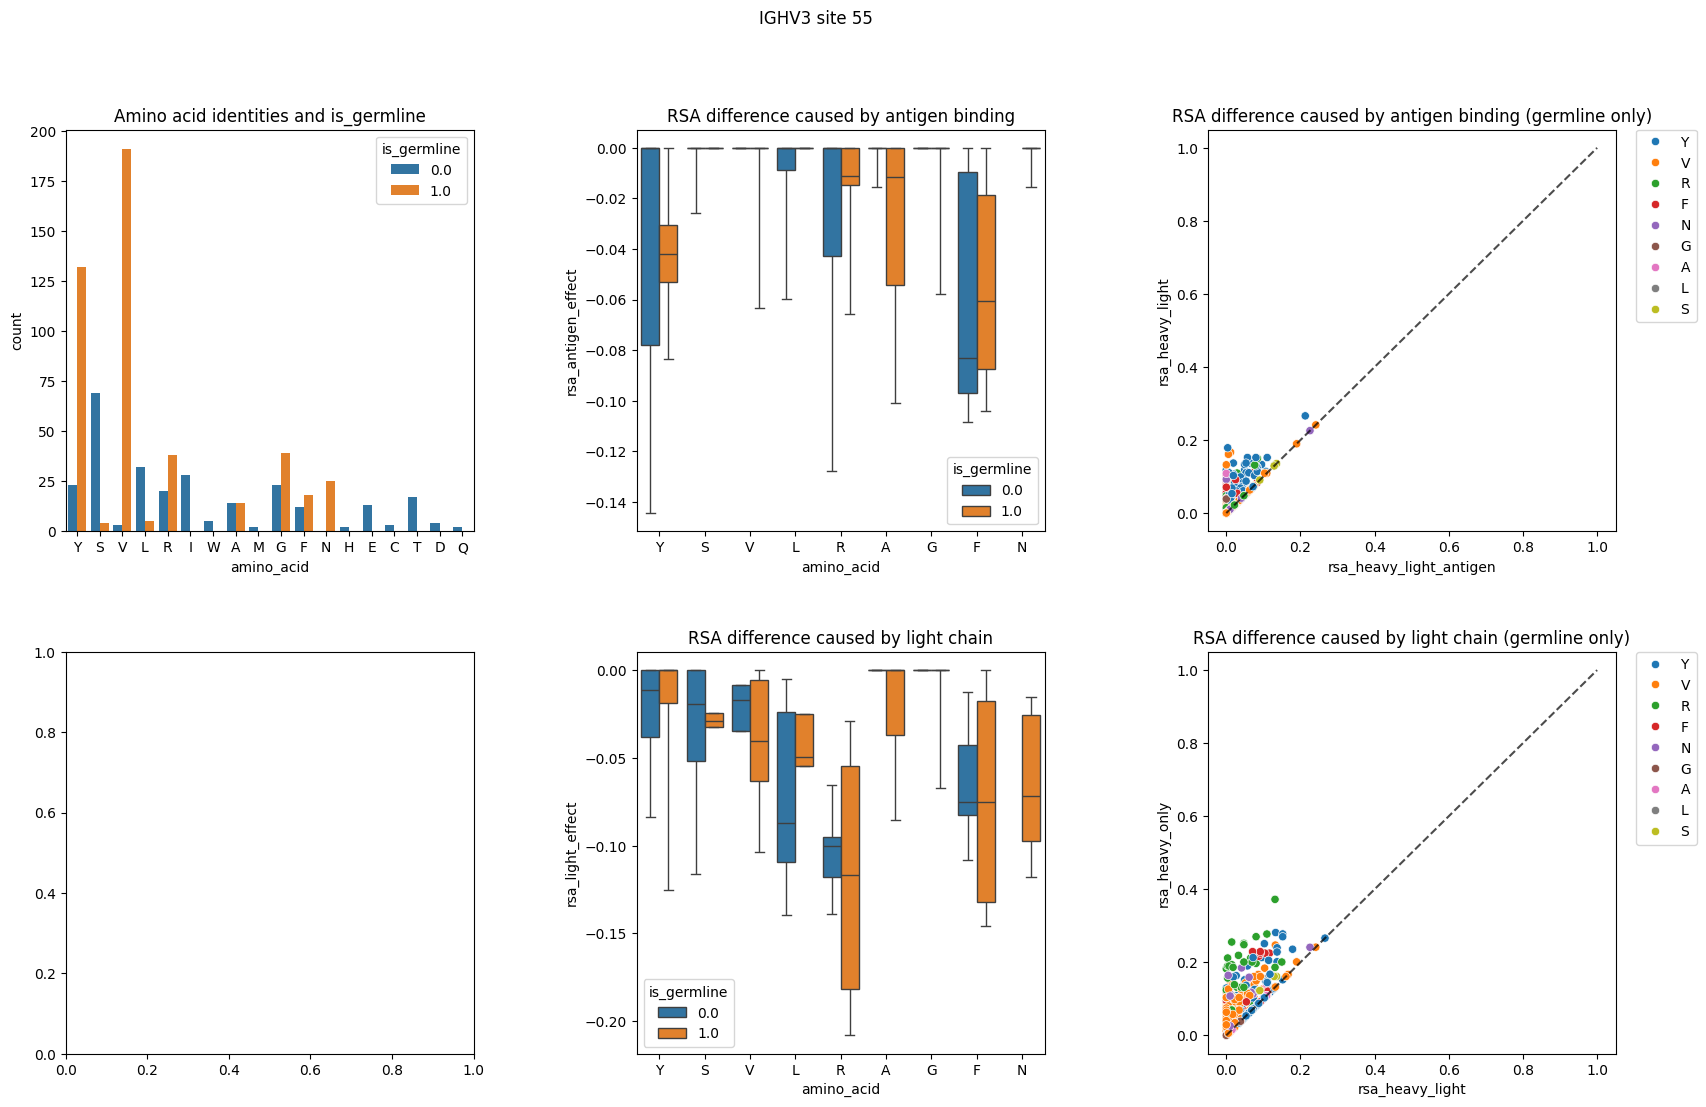

In [29]:
examine_site(df_v3, 55, 'IGHV3 site 55')


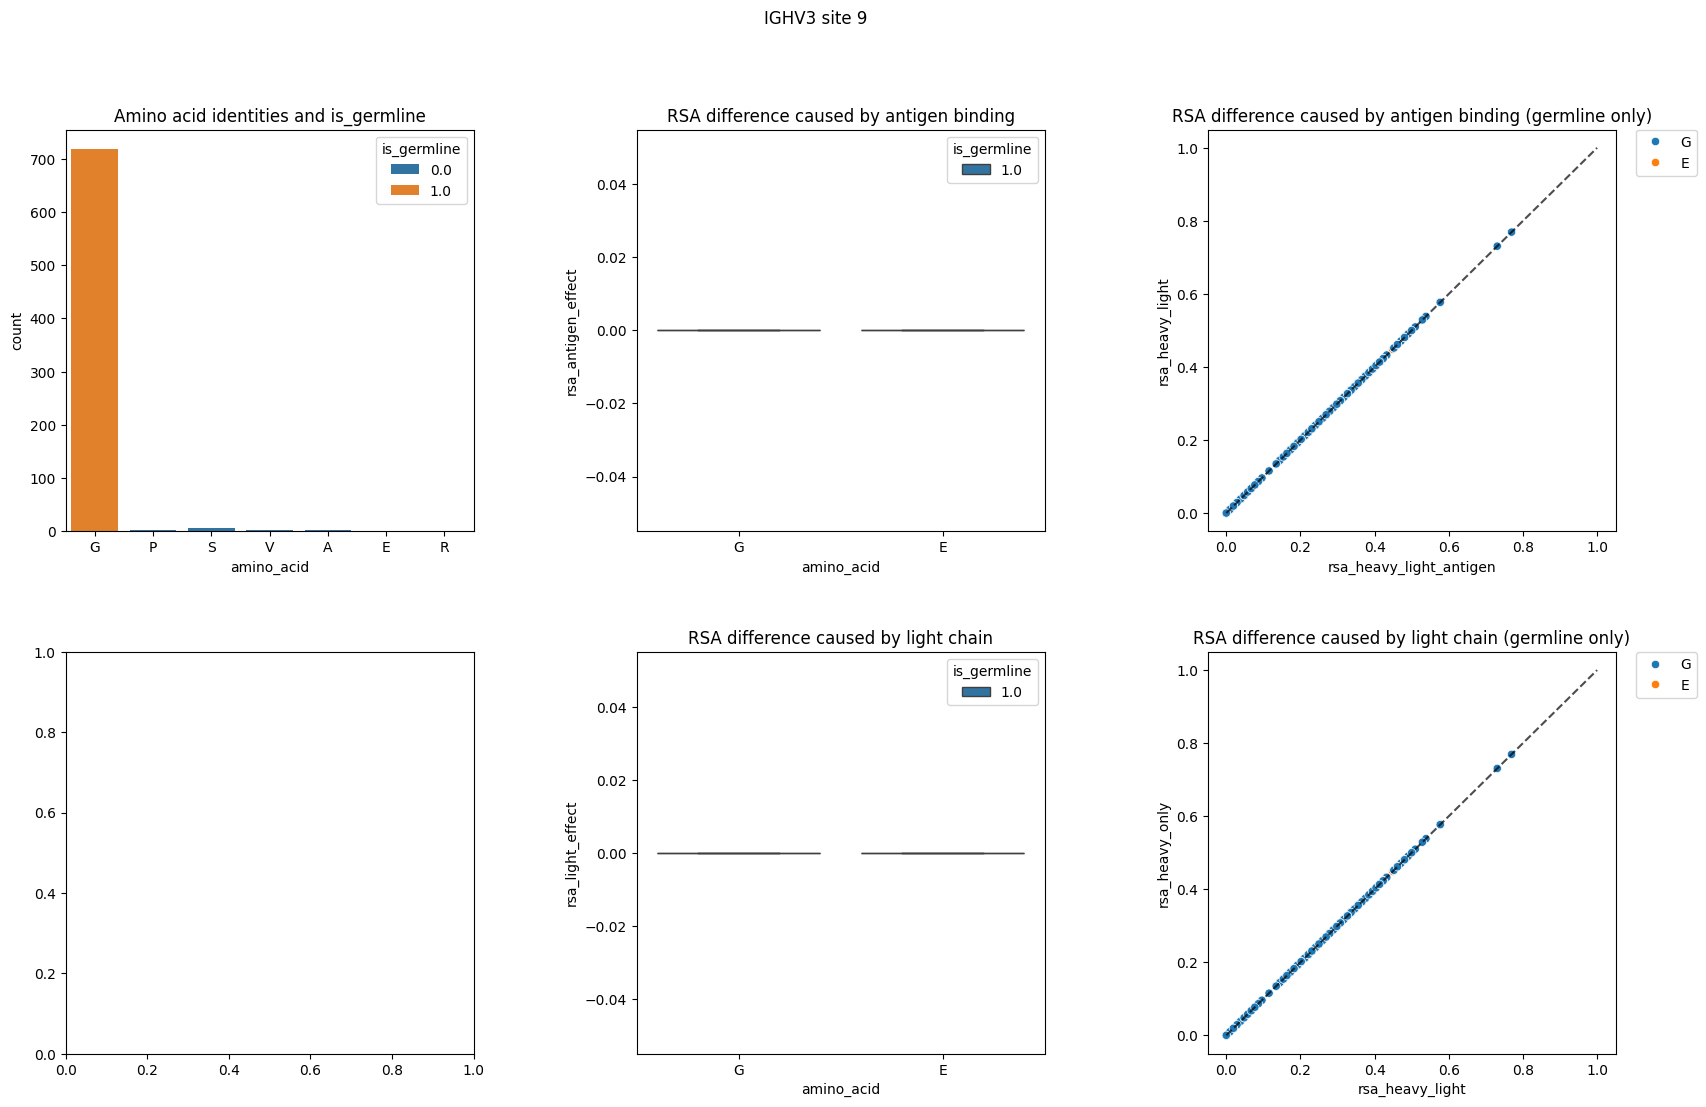

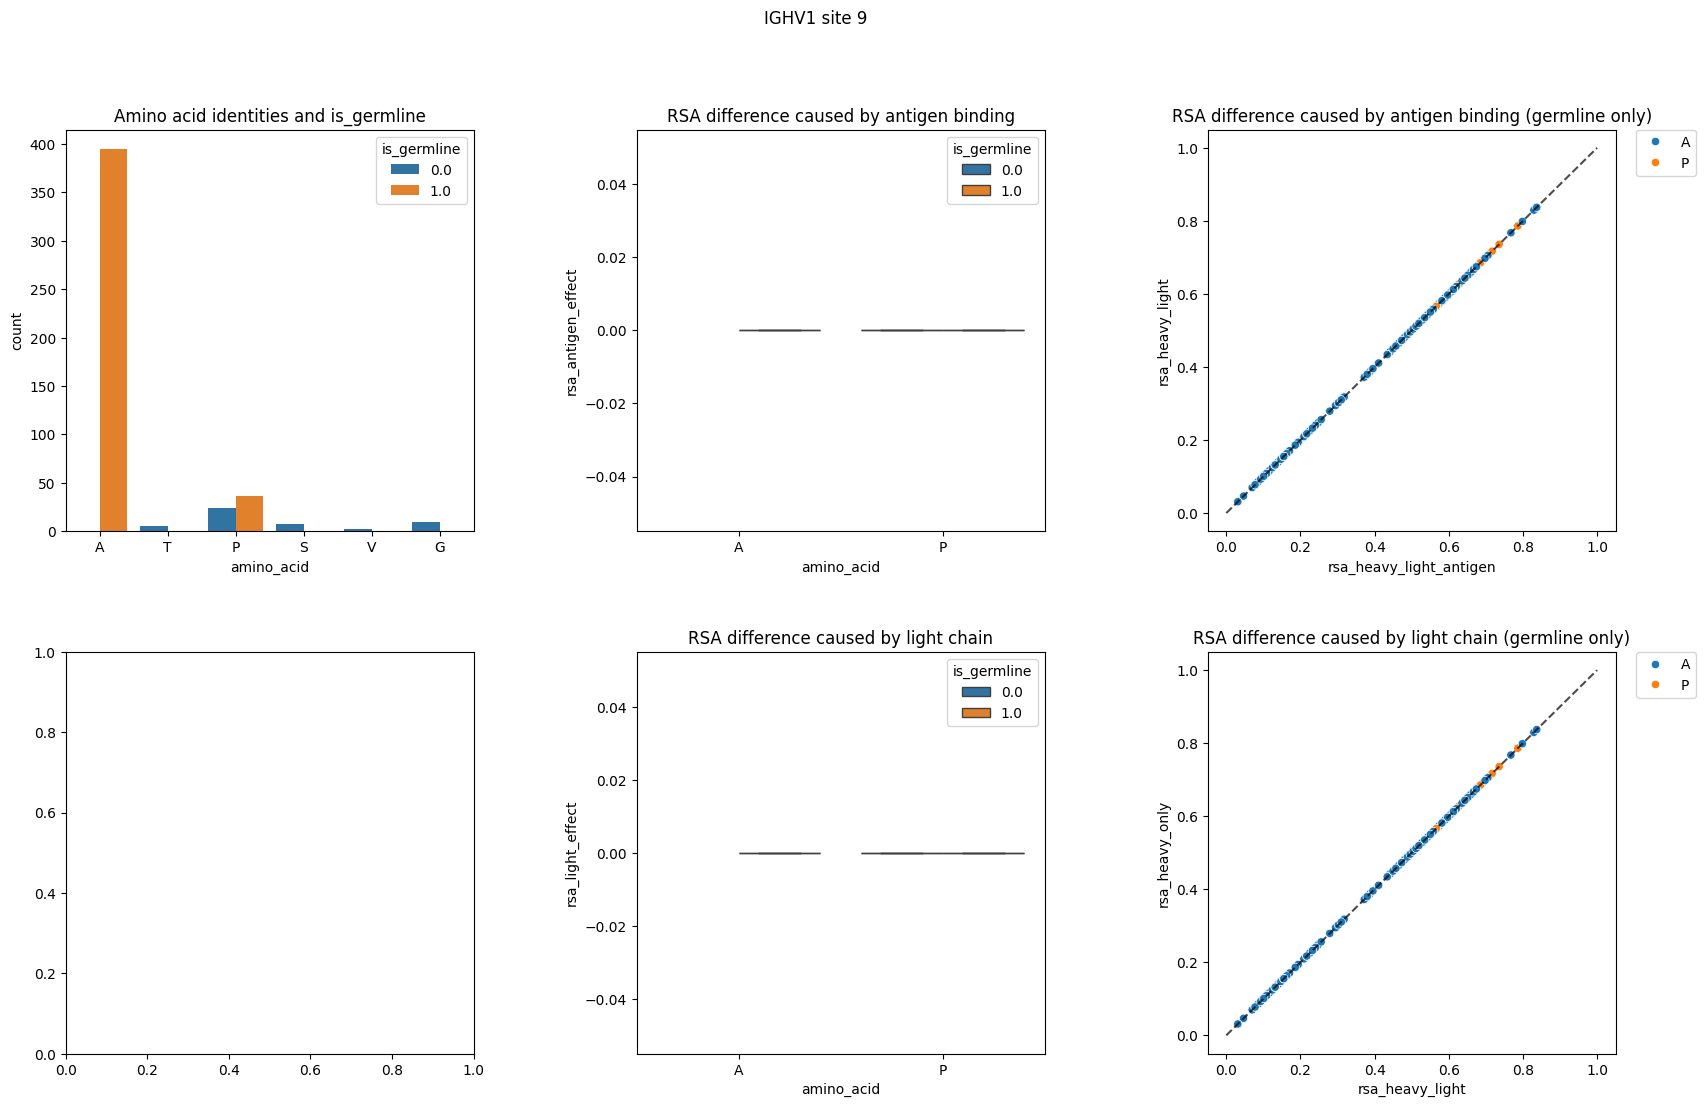

In [30]:
examine_site(df_v3, 9, 'IGHV3 site 9')
examine_site(df_v1, 9, 'IGHV1 site 9')

